# Machine Learning — Q&A Reference

Each section asks a question, gives a concise answer, and shows a runnable code example.

**Topics covered:**
1. Fundamentals
2. Data Preprocessing
3. Classification Algorithms
4. Regression Algorithms
5. Model Evaluation — Classification
6. Model Evaluation — Regression
7. Hyperparameter Tuning & Overfitting
8. Probability & Statistics
9. Advanced Topics

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer, load_diabetes, make_classification, make_regression

# Shared toy datasets used across examples
iris = load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target

cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target

diabetes = load_diabetes(as_frame=True)
X_diab, y_diab = diabetes.data, diabetes.target

print('Iris shape:    ', X_iris.shape)
print('Cancer shape:  ', X_cancer.shape)
print('Diabetes shape:', X_diab.shape)

Iris shape:     (150, 4)
Cancer shape:   (569, 30)
Diabetes shape: (442, 10)


---
# 1. Fundamentals

## Q1: What is the difference between supervised and unsupervised learning?

**Supervised** — every training example has a label (target). The model learns to map inputs → outputs.
- Classification: label is a category (spam/not spam)
- Regression: label is a number (house price)

**Unsupervised** — no labels. The model finds structure in the data itself.
- Clustering: group similar examples (K-Means)
- Dimensionality reduction: compress features (PCA)

In [61]:
from sklearn.cluster import KMeans

# --- Supervised: predict iris species (label exists) ---
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_iris, y_iris)
print('Supervised accuracy:', round(clf.score(X_iris, y_iris), 3))

# --- Unsupervised: cluster iris without using labels ---
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
km.fit(X_iris)
print('Unsupervised cluster labels:', np.unique(km.labels_))

Supervised accuracy: 0.973
Unsupervised cluster labels: [0 1 2]


## Q2: What is train-test split and why do we need it?

We hold out a portion of data the model never sees during training. This gives an honest estimate of how well the model generalises to new data.

Without it, accuracy measured on training data is optimistic — the model may have memorised it.

**`stratify=y`** preserves the class ratio in both splits — always use it for classification.

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

print('Train size:', X_train.shape[0])
print('Test  size:', X_test.shape[0])

# Class proportions should be roughly equal
print('Train class ratio:', y_train.value_counts(normalize=True).round(2).to_dict())
print('Test  class ratio:', y_test.value_counts(normalize=True).round(2).to_dict())

Train size: 455
Test  size: 114
Train class ratio: {1: 0.63, 0: 0.37}
Test  class ratio: {1: 0.63, 0: 0.37}


## Q3: What is cross-validation and when should you use it?

K-fold CV splits the data into K parts. The model is trained K times — each time one fold is the test set and the rest are training. Final score = mean across K runs.

**Why:** A single train-test split can be lucky or unlucky depending on which samples land where. CV gives a more stable, less variance-prone estimate.

**When:** Use CV for model selection and hyperparameter tuning. Use a held-out test set only for final evaluation.

CV scores per fold: [0.912 0.895 0.939 0.956 0.894]
Mean: 0.919  Std: 0.025


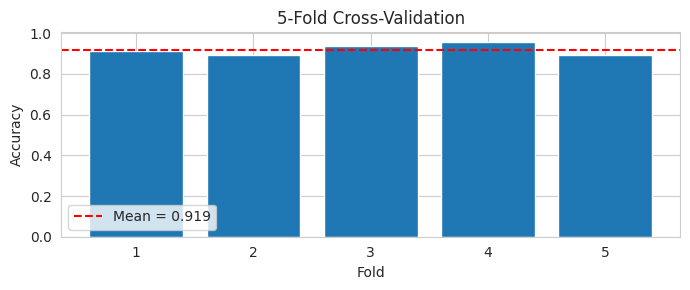

In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
scores = cross_val_score(clf, X_cancer, y_cancer, cv=5, scoring='accuracy')

print('CV scores per fold:', scores.round(3))
print(f'Mean: {scores.mean():.3f}  Std: {scores.std():.3f}')

# Visualise fold-by-fold variance
plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), scores)
plt.axhline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

## Q3b: What does a typical ML project pipeline look like?

```
Raw data
   │
   ▼
1. EDA  ──────────────── understand distributions, missing values, correlations
   │
   ▼
2. Feature Engineering ─ create/transform features (log, ratios, binning)
   │
   ▼
3. Preprocessing ──────── impute → scale → encode (inside a Pipeline!)
   │
   ▼
4. Model Selection ─────── try several algorithms with cross-validation
   │
   ▼
5. Hyperparameter Tuning ─ GridSearchCV / RandomizedSearchCV
   │
   ▼
6. Final Evaluation ─────── run once on the held-out test set, report metrics
   │
   ▼
7. Deployment ────────────── serialize pipeline (joblib), serve predictions
```

**Golden rule:** the test set is touched **exactly once** — at the very end.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib, tempfile, os

# ── Step 1: Load & EDA ───────────────────────────────────────────────────────
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')
print(f'Missing values: {X.isnull().sum().sum()}')

# ── Step 2: Train-test split (done FIRST, before any fitting) ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# ── Step 3: Build pipeline (preprocessing + model) ───────────────────────────
pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('scl', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

# ── Step 4: Model selection via cross-validation ─────────────────────────────
cv_score = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1').mean()
print(f'\nCV F1 (default RF): {cv_score:.4f}')

# ── Step 5: Hyperparameter tuning ────────────────────────────────────────────
param_grid = {'clf__n_estimators': [50, 100], 'clf__max_depth': [None, 5]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best CV F1:  {grid.best_score_:.4f}')

# ── Step 6: Final evaluation on test set (only once!) ────────────────────────
y_pred = grid.predict(X_test)
print(f'\nTest set classification report:')
print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))

# ── Step 7: Serialize pipeline ───────────────────────────────────────────────
tmp = tempfile.mktemp(suffix='.pkl')
joblib.dump(grid.best_estimator_, tmp)
loaded_pipe = joblib.load(tmp)
print(f'Serialized and reloaded pipeline predictions match: '
      f'{(loaded_pipe.predict(X_test) == y_pred).all()}')
os.unlink(tmp)


---
# 2. Data Preprocessing

## Q4: How do you handle missing values?

`SimpleImputer` fills missing values with a chosen statistic:
- `'mean'` — good for roughly symmetric numeric columns
- `'median'` — better when the column has outliers
- `'most_frequent'` — for categorical columns
- `'constant'` — fill with a fixed value

Always fit the imputer **only on training data**, then transform both train and test.

In [64]:
from sklearn.impute import SimpleImputer

# Synthetic data with missing values
data = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, np.nan],
    'salary': [50000, 60000, np.nan, 80000, 55000],
    'city':   ['NY', 'LA', np.nan, 'NY', 'LA']
})
print('Before:\n', data)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

data[['age', 'salary']] = num_imputer.fit_transform(data[['age', 'salary']])
data[['city']] = cat_imputer.fit_transform(data[['city']])

print('\nAfter:\n', data)

Before:
     age   salary city
0  25.0  50000.0   NY
1   NaN  60000.0   LA
2  35.0      NaN  NaN
3  40.0  80000.0   NY
4   NaN  55000.0   LA

After:
     age   salary city
0  25.0  50000.0   NY
1  35.0  60000.0   LA
2  35.0  57500.0   LA
3  40.0  80000.0   NY
4  35.0  55000.0   LA


## Q5: What is the difference between StandardScaler and MinMaxScaler?

| Scaler | Formula | Output range | Use when |
|---|---|---|---|
| `StandardScaler` | `(x - mean) / std` | ~[-3, 3] | Data is roughly normal; algorithms like SVM, KNN |
| `MinMaxScaler` | `(x - min) / (max - min)` | [0, 1] | Neural networks, when bounded range is required |

**Both must be fit on training data only.**  
KNN and SVM are sensitive to scale. Decision Trees and Random Forests are not.

In [65]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sample = np.array([[10], [20], [30], [1000]])  # outlier at 1000

std  = StandardScaler().fit_transform(sample)
minmax = MinMaxScaler().fit_transform(sample)

df_cmp = pd.DataFrame({'original': sample.ravel(),
                        'StandardScaler': std.ravel().round(2),
                        'MinMaxScaler': minmax.ravel().round(2)})
print(df_cmp)
# Notice: MinMaxScaler squeezes 10/20/30 near 0 because of the outlier

   original  StandardScaler  MinMaxScaler
0        10           -0.60          0.00
1        20           -0.58          0.01
2        30           -0.55          0.02
3      1000            1.73          1.00


## Q5b: What is normalization and how does it affect ML models?

"Normalization" is an umbrella term for any technique that rescales features. Three common types:

| Technique | Formula | Output | Use when |
|---|---|---|---|
| **Min-Max** | (x − min) / (max − min) | [0, 1] | Neural networks; bounded range needed |
| **Z-score (Standardisation)** | (x − μ) / σ | mean=0, std=1 | KNN, SVM, Logistic Regression |
| **L2 normalisation** | x / \|\|x\|\| | unit norm per sample | Text/NLP, cosine similarity |

**Which algorithms care?**
- **Sensitive:** KNN, SVM, Logistic Regression, Ridge/Lasso, Neural Networks
- **Not sensitive:** Decision Tree, Random Forest, Gradient Boosting — they use thresholds, not distances

**Always fit on train, transform both.** A `Pipeline` does this automatically.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

# Visual: effect of scaling on two features with very different ranges
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ['Raw (no scaling)', 'StandardScaler', 'MinMaxScaler']
datasets = [X[:, :2],
            StandardScaler().fit_transform(X[:, :2]),
            MinMaxScaler().fit_transform(X[:, :2])]

for ax, Xs, label in zip(axes, datasets, labels):
    ax.scatter(Xs[y==0, 0], Xs[y==0, 1], alpha=0.4, s=10, label='Malignant')
    ax.scatter(Xs[y==1, 0], Xs[y==1, 1], alpha=0.4, s=10, label='Benign')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Effect of scaling on feature space (first 2 features)')
plt.tight_layout()
plt.show()

# Impact on KNN accuracy
print('KNN CV accuracy by scaling:')
for name, scaler in [('No scaling',    None),
                      ('StandardScaler', StandardScaler()),
                      ('MinMaxScaler',   MinMaxScaler())]:
    steps = [('scl', scaler), ('knn', KNeighborsClassifier(n_neighbors=7))] if scaler else             [('knn', KNeighborsClassifier(n_neighbors=7))]
    pipe = Pipeline(steps)
    score = cross_val_score(pipe, X, y, cv=5).mean()
    print(f'  {name:15s}: {score:.4f}')


## Q5c: What is Pearson Correlation and how do you use it in ML?

Pearson's r measures the **linear** relationship between two variables:

```
r = cov(X, Y) / (std(X) * std(Y))
```

| r value | Meaning |
|---|---|
| +1 | Perfect positive linear relationship |
| −1 | Perfect negative linear relationship |
| 0 | No **linear** relationship (nonlinear may still exist!) |
| > 0.8 or < −0.8 | Strongly correlated |

**Uses in ML:**
1. **Feature selection:** drop one of two features with \|r\| > 0.9 (redundant)
2. **Target correlation:** find which features predict the target
3. **Multicollinearity detection:** collinear features hurt linear models (inflated coefficients)

**Limitation:** Pearson only detects *linear* relationships. Spearman's rank correlation handles monotonic but nonlinear relationships.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# ── 1. Correlation with target ────────────────────────────────────────────────
target_corr = X.corrwith(y).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
target_corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in target_corr], ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation of each feature with target (Survived=1)')
ax.set_xlabel('r')
plt.tight_layout()
plt.show()

# ── 2. Feature-feature correlation heatmap ───────────────────────────────────
corr_matrix = X.iloc[:, :10].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature-Feature Pearson Correlation (first 10 features)')
plt.tight_layout()
plt.show()

# ── 3. Pearson vs Spearman — nonlinear example ────────────────────────────────
rng = np.random.default_rng(42)
x = rng.uniform(0, 4, 200)
y_lin  = 2*x + rng.normal(0, 0.5, 200)          # linear
y_nonl = np.exp(x) + rng.normal(0, 0.5, 200)    # nonlinear monotonic

print('           Pearson r    Spearman rho')
for label, yv in [('Linear', y_lin), ('Nonlinear (exp)', y_nonl)]:
    pr, _ = pearsonr(x, yv)
    sr, _ = spearmanr(x, yv)
    print(f'{label:18s}  {pr:.4f}        {sr:.4f}')
print('Spearman handles nonlinear monotonic relationships better')


## Q6: What is One-Hot Encoding and when do you need it?

Most ML algorithms require numeric input. A categorical column like `['cat', 'dog', 'bird']` can't be passed as-is — encoding it as 1/2/3 would imply an order that doesn't exist.

One-hot encoding creates one binary column per category:

```
cat  → [1, 0, 0]
dog  → [0, 1, 0]
bird → [0, 0, 1]
```

Use `handle_unknown='ignore'` so unseen categories in test data don't crash the model.

In [66]:
from sklearn.preprocessing import OneHotEncoder

animals = pd.DataFrame({'animal': ['cat', 'dog', 'bird', 'dog', 'cat']})

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = enc.fit_transform(animals[['animal']])

result = pd.DataFrame(encoded, columns=enc.get_feature_names_out())
print(result)

   animal_bird  animal_cat  animal_dog
0          0.0         1.0         0.0
1          0.0         0.0         1.0
2          1.0         0.0         0.0
3          0.0         0.0         1.0
4          0.0         1.0         0.0


## Q7: What is a sklearn Pipeline and why should you always use one?

A `Pipeline` chains preprocessing steps and a model into a single object. Benefits:

1. **No data leakage** — the scaler/imputer is fitted only on training data inside `cross_val_score` or `GridSearchCV`.
2. **One `.fit()` / `.predict()` call** — cleaner code.
3. **Deployable** — the whole pipeline can be saved and loaded as one unit.

Without a pipeline, if you scale *before* splitting, test-set statistics leak into training — your CV scores are optimistic.

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5))
])

# cross_val_score fits the scaler fresh on each train fold — no leakage
scores = cross_val_score(pipe, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'Pipeline CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}')

Pipeline CV accuracy: 0.965 ± 0.010


## Q8: What is ColumnTransformer?

Real datasets have mixed types: some columns are numeric, some categorical. `ColumnTransformer` lets you apply different preprocessing to different columns, then concatenate the results.

```
numeric cols  → impute(median) → StandardScaler  ─┐
                                                    ├→ combined feature matrix
category cols → impute(mode)   → OneHotEncoder   ─┘
```

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Synthetic mixed dataset
df = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, 28],
    'income': [50, 60, np.nan, 80, 55],
    'gender': ['M', 'F', 'M', np.nan, 'F'],
    'city':   ['NY', 'LA', 'NY', 'LA', 'NY']
})
y = np.array([0, 1, 0, 1, 0])

num_cols = ['age', 'income']
cat_cols = ['gender', 'city']

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeClassifier())])
pipe.fit(df, y)

transformed = preprocessor.fit_transform(df)
print('Output shape:', transformed.shape, '  (2 numeric + 2+2 one-hot columns)')

Output shape: (5, 6)   (2 numeric + 2+2 one-hot columns)


---
# 3. Classification Algorithms

## Q9: How does K-Nearest Neighbors (KNN) work?

For a new point, KNN finds the K closest training examples (by distance) and takes a majority vote among their labels.

**Key hyperparameters:**
- `n_neighbors` (K) — small K → complex boundary (risk overfitting); large K → smoother (risk underfitting)
- `weights` — `'uniform'` (all neighbours equal) vs `'distance'` (closer ones count more)

**Requires scaling** — distance is meaningless if features are on different scales.

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

results = {}
for k in [1, 5, 15, 30]:
    pipe = Pipeline([('scl', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    results[k] = round(score, 3)

print('K → CV accuracy')
for k, s in results.items():
    print(f'  K={k:2d}: {s}')

K → CV accuracy
  K= 1: 0.954
  K= 5: 0.965
  K=15: 0.961
  K=30: 0.953


## Q10: How does a Decision Tree work?

A decision tree repeatedly splits the data on the feature + threshold that best separates the classes. At each node it asks a yes/no question (e.g. `petal_length < 2.45`). Leaf nodes hold the final predictions.

**Split criteria:**
- `gini` — measures impurity: 0 = pure node, 0.5 = maximum impurity
- `entropy` — information gain; slightly slower but often similar results

**Key hyperparameters:** `max_depth`, `min_samples_split`, `min_samples_leaf`

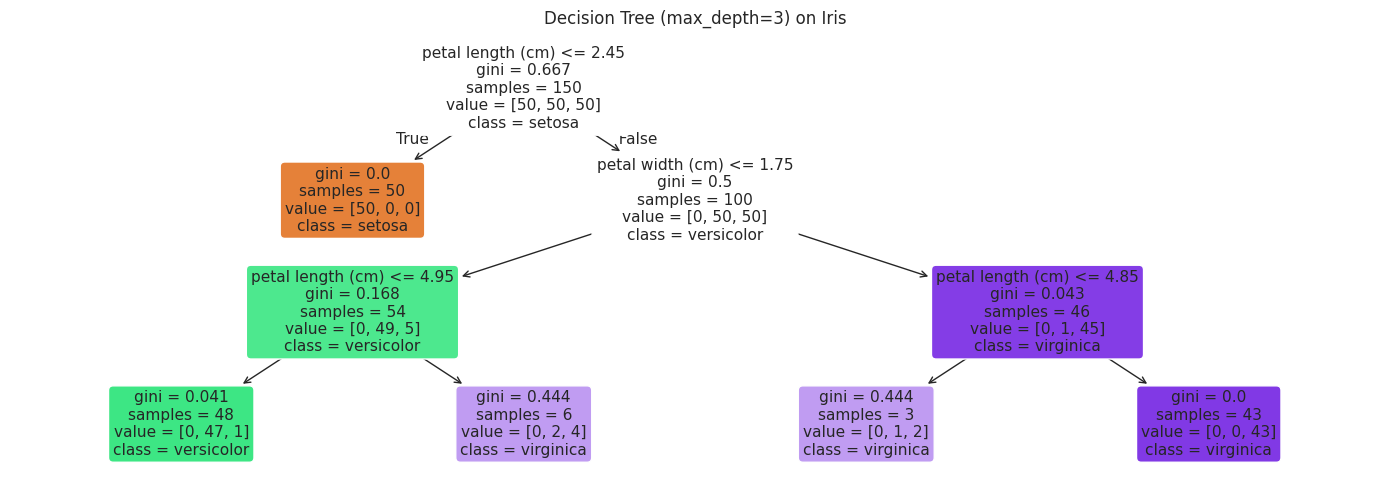

Train accuracy: 0.973
CV accuracy:    0.973


In [70]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_iris, y_iris)

plt.figure(figsize=(14, 5))
plot_tree(dt, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree (max_depth=3) on Iris')
plt.tight_layout()
plt.show()

print('Train accuracy:', round(dt.score(X_iris, y_iris), 3))
print('CV accuracy:   ', round(cross_val_score(dt, X_iris, y_iris, cv=5).mean(), 3))

## Q10b: Gini Impurity vs Entropy — what's the difference and which should you use?

Both measure **node impurity** — how mixed the classes are at a split. A pure node (one class only) scores 0 on both.

| | Formula | Range | Speed |
|---|---|---|---|
| **Gini** | `1 - Σ pᵢ²` | [0, 0.5] for binary | Faster (no log) |
| **Entropy** | `-Σ pᵢ log₂(pᵢ)` | [0, 1] for binary | Slightly slower |

**In practice:** both almost always produce the same tree structure and similar accuracy. Default to `gini` (faster). Switch to `entropy` if you care about information-theoretic interpretability.

A split is chosen to **maximise Information Gain** = impurity(parent) − weighted average impurity(children).

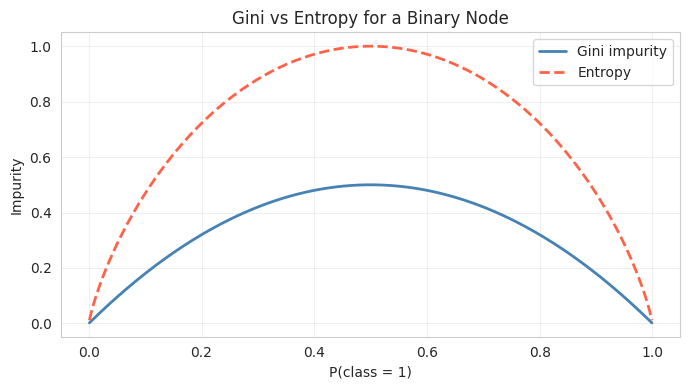

Parent gini:      0.5000
Left  gini:       0.2778  (6 samples: 5A, 1B)
Right gini:       0.0000  (4 samples: 0B, 4B = pure!)
Weighted child:   0.1667
Information Gain: 0.3333  ← the tree maximises this

CV accuracy comparison on Breast Cancer:
  criterion=gini   : 0.9191
  criterion=entropy: 0.9350
(difference is typically negligible)


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# ── 1. Gini vs Entropy formula comparison ────────────────────────────────────
p = np.linspace(0.001, 0.999, 300)   # p = prob of class 1
gini    = 1 - (p**2 + (1-p)**2)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))

plt.figure(figsize=(7, 4))
plt.plot(p, gini,    label='Gini impurity', color='steelblue', linewidth=2)
plt.plot(p, entropy, label='Entropy',       color='tomato',    linewidth=2, linestyle='--')
plt.xlabel('P(class = 1)')
plt.ylabel('Impurity')
plt.title('Gini vs Entropy for a Binary Node')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Information Gain example (manual) ─────────────────────────────────────
# Parent: 10 samples, 5 class-A, 5 class-B  → impurity = 0.5
# Split into Left (6 samples: 5A, 1B) and Right (4 samples: 0A, 4B)
def gini_node(pos, total):
    if total == 0: return 0
    p = pos / total
    return 1 - p**2 - (1-p)**2

parent_gini = gini_node(5, 10)
left_gini   = gini_node(5, 6)
right_gini  = gini_node(0, 4)
weighted    = (6/10) * left_gini + (4/10) * right_gini
info_gain   = parent_gini - weighted

print(f'Parent gini:      {parent_gini:.4f}')
print(f'Left  gini:       {left_gini:.4f}  (6 samples: 5A, 1B)')
print(f'Right gini:       {right_gini:.4f}  (4 samples: 0B, 4B = pure!)')
print(f'Weighted child:   {weighted:.4f}')
print(f'Information Gain: {info_gain:.4f}  ← the tree maximises this')

# ── 3. Accuracy comparison: gini vs entropy ───────────────────────────────────
print('\nCV accuracy comparison on Breast Cancer:')
for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier(max_depth=5, criterion=criterion, random_state=42)
    score = cross_val_score(dt, X_cancer, y_cancer, cv=5).mean()
    print(f'  criterion={criterion:7s}: {score:.4f}')
print('(difference is typically negligible)')

## Q11: What is Random Forest and why is it better than a single Decision Tree?

Random Forest trains many decision trees on **random subsets** of data (bagging) and random subsets of features. Predictions are made by majority vote across all trees.

**Why it's better:**
- A single deep tree overfits. Many trees averaging out their errors gives a more stable prediction.
- The feature randomness (`max_features`) ensures trees are diverse and their errors are uncorrelated.

**Key hyperparameters:** `n_estimators` (more = better, but slower), `max_depth`, `max_features`

In [72]:
from sklearn.ensemble import RandomForestClassifier

single_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(single_tree,  X_cancer, y_cancer, cv=5)
rf_scores  = cross_val_score(random_forest, X_cancer, y_cancer, cv=5)

print(f'Single Tree CV: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}')
print(f'Random Forest CV: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
# RF should be higher accuracy AND lower std (more stable)

Single Tree CV: 0.917 ± 0.024
Random Forest CV: 0.956 ± 0.023


## Q12: What is Logistic Regression? (Despite the name, it's a classifier.)

Logistic Regression models the **probability** of a class using the sigmoid function:

```
P(y=1 | x) = 1 / (1 + e^(-w·x))
```

If P > 0.5 → class 1, else class 0. Unlike a Decision Tree, the decision boundary is a straight line (linear).

**Hyperparameter `C`:** inverse of regularisation strength. Small C = more regularisation (simpler model).

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scl', StandardScaler()),
    ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

scores = cross_val_score(pipe, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'Logistic Regression CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Inspect learned coefficients (after fitting on full data)
pipe.fit(X_cancer, y_cancer)
coef = pipe.named_steps['lr'].coef_[0]
top5 = pd.Series(np.abs(coef), index=X_cancer.columns).nlargest(5)
print('\nTop 5 most influential features:')
print(top5.round(3))

Logistic Regression CV: 0.981 ± 0.007

Top 5 most influential features:
worst texture    1.321
radius error     1.289
worst radius     1.027
area error       0.999
worst area       0.995
dtype: float64


## Q13: What is Naive Bayes?

Naive Bayes applies Bayes' theorem with the "naive" assumption that features are **independent** given the class:

```
P(class | features) ∝ P(class) × ∏ P(feature_i | class)
```

This is almost never true in real data, but the classifier still works surprisingly well — especially for text classification.

**Variants:**
- `GaussianNB` — numeric features assumed to be normally distributed
- `MultinomialNB` — word counts (text)
- `BernoulliNB` — binary features

In [74]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
scores = cross_val_score(nb, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'GaussianNB CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Bayes' theorem example (manual)
# P(disease | positive test) given:
p_disease  = 0.01   # prevalence
p_pos_given_disease = 0.99   # sensitivity
p_pos_given_no_disease = 0.05  # false positive rate

p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * (1 - p_disease)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f'\nBayes example: P(disease | positive test) = {p_disease_given_pos:.3f}')
print('Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%')

GaussianNB CV: 0.939 ± 0.015

Bayes example: P(disease | positive test) = 0.167
Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%


## Q14: What is Support Vector Machine (SVM)?

SVM finds the **maximum-margin hyperplane** — the decision boundary that is as far as possible from the nearest data points (support vectors) of each class.

**The kernel trick** maps data to a higher-dimensional space, allowing non-linear boundaries without explicitly computing the transformation.

**Key hyperparameters:**
- `C` — trade-off between margin width and misclassification
- `kernel` — `'linear'`, `'rbf'` (most common), `'poly'`
- `gamma` — how far the influence of each training point reaches (for rbf)

In [75]:
from sklearn.svm import SVC

# SVM requires scaling
for kernel in ['linear', 'rbf']:
    pipe = Pipeline([
        ('scl', StandardScaler()),
        ('svm', SVC(kernel=kernel, C=1.0, random_state=42))
    ])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    print(f'SVM ({kernel:6s}) CV accuracy: {score:.3f}')

SVM (linear) CV accuracy: 0.972
SVM (rbf   ) CV accuracy: 0.974


---
# 4. Regression Algorithms

## Q15: What is Linear Regression (Ordinary Least Squares)?

OLS finds the line (or hyperplane) that minimises the sum of squared residuals:

```
Loss = Σ (y_i - ŷ_i)²
```

The closed-form solution is:
```
w = (XᵀX)⁻¹ Xᵀy
```

This has an exact answer — no iterations needed (unlike gradient descent). However it becomes slow when the number of features is very large.

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print('MAE: ', round(mean_absolute_error(y_test, y_pred), 2))
print('R²:  ', round(r2_score(y_test, y_pred), 3))

# OLS closed form (manual, 1-feature example)
X_simple = X_diab[['bmi']].values
X_b = np.hstack([np.ones((len(X_simple), 1)), X_simple])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_diab.values
print(f'\nOLS (manual) — intercept: {w_ols[0]:.2f}, bmi coef: {w_ols[1]:.2f}')

MAE:  42.79
R²:   0.453

OLS (manual) — intercept: 152.13, bmi coef: 949.44


## Q16: What is Gradient Descent?

An iterative optimisation algorithm. At each step, move the weights in the direction that decreases the loss most (the negative gradient):

```
w := w - α × ∇Loss(w)
```

Where α is the **learning rate**:
- Too small → converges slowly
- Too large → overshoots, may diverge

Used when the matrix inversion of OLS would be too expensive (many features) or when there's no closed form (neural networks).

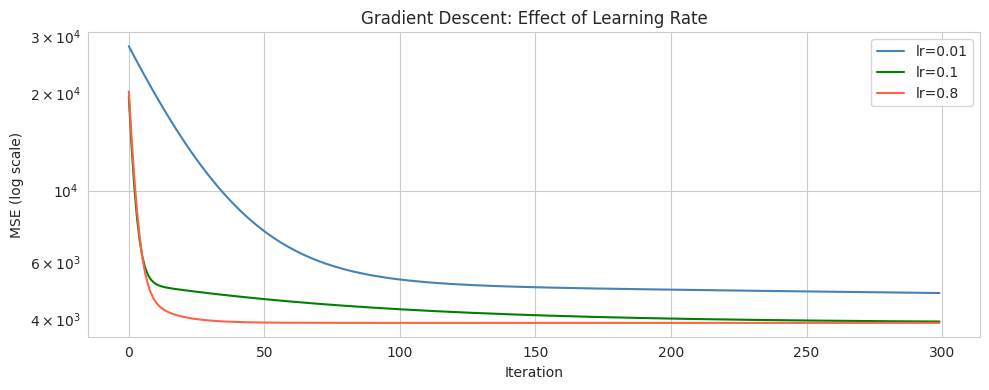

In [77]:
# Gradient descent for linear regression (from scratch)
X_raw = X_diab[['bmi']].values
X_norm = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())  # normalise to [0,1]
X_b = np.hstack([np.ones((len(X_norm), 1)), X_norm])
y = y_diab.values

def mse(w, X, y):
    return np.mean((X @ w - y) ** 2)

plt.figure(figsize=(10, 4))

for lr_val, color in [(0.01, 'steelblue'), (0.1, 'green'), (0.8, 'tomato')]:
    w = np.zeros(2)
    losses = []
    for _ in range(300):
        grad = (2 / len(y)) * X_b.T @ (X_b @ w - y)
        w = w - lr_val * grad
        losses.append(mse(w, X_b, y))
    plt.plot(losses, label=f'lr={lr_val}', color=color)

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE (log scale)')
plt.title('Gradient Descent: Effect of Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Q17: What is Regularisation (Ridge / Lasso)?

Regularisation adds a penalty to the loss function to prevent large coefficients (overfitting):

| Method | Penalty | Effect |
|---|---|---|
| **Ridge (L2)** | `α × Σ w²` | Shrinks all weights toward zero, keeps all features |
| **Lasso (L1)** | `α × Σ |w|` | Forces some weights exactly to zero — **feature selection** |
| **ElasticNet** | mix of L1 + L2 | Combines both |

`alpha` controls strength. Higher alpha → more regularisation → simpler model.

In [78]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

for alpha in [0.01, 1.0, 10.0]:
    pipe_ridge = Pipeline([('scl', StandardScaler()), ('reg', Ridge(alpha=alpha))])
    pipe_lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=alpha))])

    r_ridge = cross_val_score(pipe_ridge, X_diab, y_diab, cv=5, scoring='r2').mean()
    r_lasso = cross_val_score(pipe_lasso, X_diab, y_diab, cv=5, scoring='r2').mean()
    print(f'alpha={alpha:5.2f}  Ridge R²={r_ridge:.3f}  Lasso R²={r_lasso:.3f}')

# Lasso with enough alpha zeroes some coefficients entirely
lasso = Pipeline([('scl', StandardScaler()), ('reg', Lasso(alpha=1.0))])
lasso.fit(X_diab, y_diab)
coef = pd.Series(lasso.named_steps['reg'].coef_, index=X_diab.columns)
print('\nLasso coefficients (0 = feature dropped):')
print(coef.round(2))

alpha= 0.01  Ridge R²=0.482  Lasso R²=0.482
alpha= 1.00  Ridge R²=0.482  Lasso R²=0.482
alpha=10.00  Ridge R²=0.481  Lasso R²=0.439

Lasso coefficients (0 = feature dropped):
age    -0.00
sex    -9.32
bmi    24.83
bp     14.09
s1     -4.84
s2     -0.00
s3    -10.62
s4      0.00
s5     24.42
s6      2.56
dtype: float64


## Q17b: How do Ridge and Lasso actually differ — geometry and interpretation?

**Ridge (L2)** constrains weights to a sphere: all coefficients shrink proportionally toward zero, none reach exactly zero. Good when **all features matter a little**.

**Lasso (L1)** constrains weights to a diamond: the corners sit on the axes, so the optimum often lands exactly on a corner — meaning **some coefficients become exactly zero** (automatic feature selection). Good when you suspect many features are irrelevant.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | $\\alpha \\sum w_i^2$ | $\\alpha \\sum |w_i|$ |
| Zeroes weights? | No | Yes |
| Use when | All features relevant | Many irrelevant features |

**`alpha`:** higher → more regularisation → simpler model. Choose via `RidgeCV`/`LassoCV` or `GridSearchCV`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

X_d, y_d = load_diabetes(as_frame=True, return_X_y=True)
feature_names = X_d.columns.tolist()
X_sc = StandardScaler().fit_transform(X_d)

alphas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=a).fit(X_sc, y_d).coef_ for a in alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=5000).fit(X_sc, y_d).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, coefs, title in [
        (axes[0], ridge_coefs, 'Ridge (L2) — coefficients never reach 0'),
        (axes[1], lasso_coefs, 'Lasso (L1) — coefficients shrink to exactly 0')]:
    for j, name in enumerate(feature_names):
        ax.plot(alphas, coefs[:, j], label=name)
    ax.set_xscale('log')
    ax.set_xlabel('alpha  →')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Ridge vs Lasso: how coefficients shrink as alpha increases')
plt.tight_layout()
plt.show()

# Which features does Lasso zero out?
lasso_fit = Lasso(alpha=0.5, max_iter=5000).fit(X_sc, y_d)
kept = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c != 0]
zeroed = [(n, c) for n, c in zip(feature_names, lasso_fit.coef_) if c == 0]
print(f'Lasso (alpha=0.5): {len(kept)} kept, {len(zeroed)} zeroed')
print('Kept:  ', [n for n, _ in kept])
print('Zeroed:', [n for n, _ in zeroed])

---
# 5. Model Evaluation — Classification

## Q18: What is a Confusion Matrix?

A confusion matrix shows the **counts** of correct and incorrect predictions broken down by class:

```
                 Predicted
              Neg    Pos
Actual  Neg  [ TN    FP ]
        Pos  [ FN    TP ]
```

- **TP** True Positive: correctly predicted positive
- **TN** True Negative: correctly predicted negative
- **FP** False Positive (Type I error): predicted positive, actually negative
- **FN** False Negative (Type II error): predicted negative, actually positive

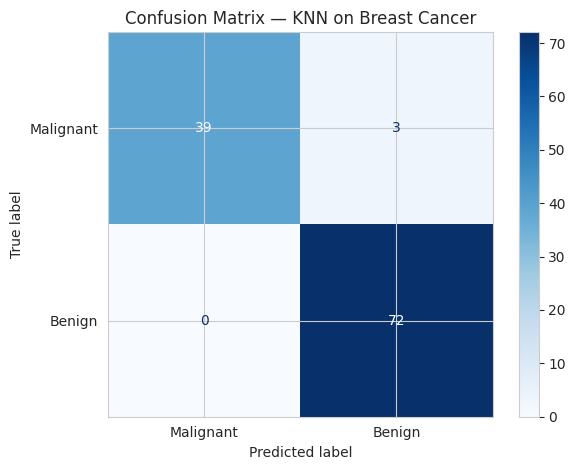

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

pipe = Pipeline([('scl', StandardScaler()),
                 ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q19: What is Accuracy, Precision, Recall, and F1-score?

| Metric | Formula | Answers |
|---|---|---|
| **Accuracy** | (TP+TN) / all | What fraction is correct overall? |
| **Precision** | TP / (TP+FP) | Of everything I said was positive, how many actually were? |
| **Recall** | TP / (TP+FN) | Of all actual positives, how many did I catch? |
| **F1** | 2 × P×R / (P+R) | Harmonic mean — balance between precision and recall |

**When accuracy is misleading:** If 95% of emails are not spam, a model that always predicts "not spam" gets 95% accuracy but never catches spam. Precision/recall tell the real story.

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1 score:  {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Accuracy:  0.974
Precision: 0.960
Recall:    1.000
F1 score:  0.980

              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Q20: What is ROC-AUC and how do you interpret it?

The **ROC curve** plots True Positive Rate vs False Positive Rate at every possible classification threshold (0 → 1).

**AUC (Area Under Curve):**
- 1.0 = perfect classifier
- 0.5 = random guessing (diagonal line)
- < 0.5 = worse than random

AUC is **threshold-independent** — it tells you how well the model ranks positives above negatives, regardless of where you set the cutoff. Useful when class imbalance makes accuracy misleading.

ROC-AUC: 0.988


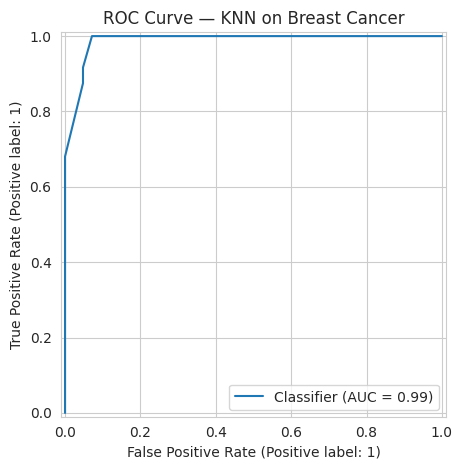

In [81]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Need predict_proba for ROC
pipe_proba = Pipeline([('scl', StandardScaler()),
                       ('knn', KNeighborsClassifier(n_neighbors=7))])
pipe_proba.fit(X_train, y_train)
y_proba = pipe_proba.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — KNN on Breast Cancer')
plt.tight_layout()
plt.show()

## Q20b: When should you use which classification metric — and how to interpret?

| Metric | Use when | Watch out for |
|---|---|---|
| **Accuracy** | Classes balanced | Misleading on imbalanced data |
| **Precision** | FP is costly (spam filter, alert fatigue) | High-recall model flags everything |
| **Recall** | FN is costly (cancer detection, fraud) | High-precision model misses real cases |
| **F1** | Need balance between P and R | Hides *which* type of error is worse |
| **ROC-AUC** | Threshold-independent model comparison | Doesn't pick an operating point |

**How to read values:**
- Accuracy `0.95` on a 95/5 dataset: always predicting the majority also gets 0.95. Useless.
- Precision `0.80`: 80% of your predicted positives are truly positive.
- Recall `0.60`: you catch 60% of all real positives — miss 40%.
- F1 `0.70`: harmonic mean of P and R — a single balanced score.
- AUC `0.97`: the model ranks a random positive above a random negative 97% of the time.

**Rule of thumb:** medicine → maximise recall (don't miss). Spam filter → maximise precision (don't bin real mail).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score,
                              precision_recall_curve, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print('Balanced vs imbalanced — why accuracy lies:')
for ratio, label in [((0.5, 0.5), 'Balanced (50/50)'),
                      ((0.95, 0.05), 'Imbalanced (95/5)')]:
    X, y = make_classification(n_samples=1000, weights=ratio, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                               stratify=y, random_state=42)
    pipe = Pipeline([('scl', StandardScaler()),
                     ('lr', LogisticRegression(max_iter=500))])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]
    naive = np.zeros_like(y_te)  # always predict majority
    print(f'\n  {label}')
    print(f'    Naive baseline accuracy: {accuracy_score(y_te, naive):.3f}')
    print(f'    Model accuracy:          {accuracy_score(y_te, y_pred):.3f}')
    print(f'    Model precision:         {precision_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model recall:            {recall_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model F1:                {f1_score(y_te, y_pred, zero_division=0):.3f}')
    print(f'    Model ROC-AUC:           {roc_auc_score(y_te, y_proba):.3f}')

# Precision-Recall trade-off at different thresholds
X, y = make_classification(n_samples=1000, weights=(0.9, 0.1), random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipe = Pipeline([('scl', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
prec, rec, _ = precision_recall_curve(y_te, proba)
fpr, tpr, _  = roc_curve(y_te, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec, color='steelblue', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(lower threshold raises recall, lowers precision)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(fpr, tpr, color='tomato', linewidth=2,
             label=f'AUC = {roc_auc_score(y_te, proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 6. Model Evaluation — Regression

## Q21: What is MAE, MSE, and RMSE?

| Metric | Formula | Properties |
|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | Same units as target; robust to outliers |
| **MSE** | mean((y - ŷ)²) | Penalises large errors heavily; not in original units |
| **RMSE** | √MSE | Same units as target; also penalises large errors |

Choose **MAE** when outliers shouldn't be penalised heavily (e.g. house prices). Choose **RMSE** when large errors are especially costly.

MAE:  44.05
MSE:  2952.01
RMSE: 54.33
R²:   0.443


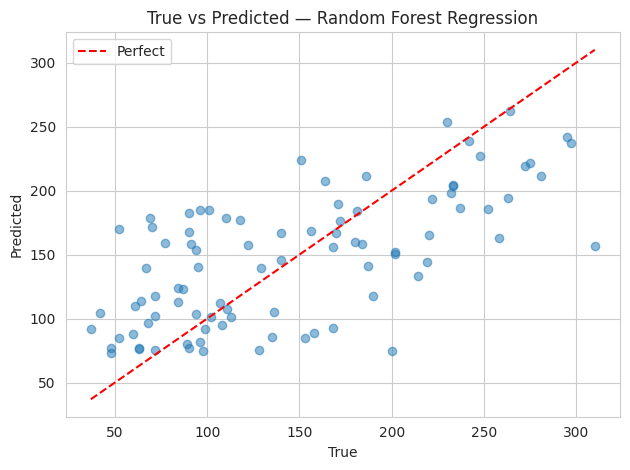

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

X_tr, X_te, y_tr, y_te = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_hat = rf.predict(X_te)

mae  = mean_absolute_error(y_te, y_hat)
mse  = mean_squared_error(y_te, y_hat)
rmse = np.sqrt(mse)
r2   = r2_score(y_te, y_hat)

print(f'MAE:  {mae:.2f}')
print(f'MSE:  {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.3f}')

plt.scatter(y_te, y_hat, alpha=0.5)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', label='Perfect')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('True vs Predicted — Random Forest Regression')
plt.legend()
plt.tight_layout()
plt.show()

## Q22: What is R² (coefficient of determination)?

R² measures what proportion of variance in the target is explained by the model:

```
R² = 1 - (SS_res / SS_tot)
   = 1 - Σ(y-ŷ)² / Σ(y-mean(y))²
```

- R² = 1.0 → perfect predictions
- R² = 0.0 → model does no better than predicting the mean
- R² < 0  → model is worse than predicting the mean

Unlike RMSE, R² is **scale-independent**, making it easy to compare across datasets.

In [83]:
y_true = np.array([3, -0.5, 2, 7])
y_pred_good  = np.array([2.5,  0.0, 2, 8])
y_pred_mean  = np.full_like(y_true, y_true.mean(), dtype=float)  # always predict mean
y_pred_bad   = np.array([10,  10,  10, 10])  # terrible model

for label, yp in [('Good model', y_pred_good),
                   ('Mean baseline', y_pred_mean),
                   ('Bad model', y_pred_bad)]:
    print(f'{label:15s}  R² = {r2_score(y_true, yp):.3f}')

Good model       R² = 0.949
Mean baseline    R² = 0.000
Bad model        R² = -6.957


## Q22b: How to choose and interpret regression metrics?

| Metric | Same units? | Penalises outliers? | Use when |
|---|---|---|---|
| **MAE** | Yes | No (linear) | Outliers present; interpretable error |
| **MSE** | No (squared) | Yes (quadratic) | Rarely reported; used in loss functions |
| **RMSE** | Yes | Yes (quadratic) | Large errors especially costly |
| **R²** | No (0–1) | — | Scale-free comparison across datasets |

**How to interpret:**
- MAE = 42 on house prices (in $k) → on average predictions are off by $42k.
- RMSE = 65 >> MAE = 42 → a few predictions are wildly off (outlier residuals).
- R² = 0.85 → model explains 85% of the variance.
- R² = 0.0 → no better than predicting the mean every time.
- R² < 0 → model is *worse* than the mean baseline.

**Residual plot:** predicted vs (true − predicted). Should be a horizontal band around 0. Patterns (funnel, curve) reveal problems.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(42)
y_true = rng.normal(100, 20, 200)
y_good    = y_true + rng.normal(0, 5, 200)
y_outlier = y_true + rng.normal(0, 5, 200)
y_outlier[:5] += 200  # 5 catastrophic errors
y_mean_pred = np.full_like(y_true, y_true.mean())

print(f'  {"Model":15s}  {"MAE":>7}  {"RMSE":>7}  {"R2":>7}  Gap(RMSE-MAE)')
print('-' * 60)
for name, yp in [('Good model', y_good),
                  ('Outlier model', y_outlier),
                  ('Mean baseline', y_mean_pred)]:
    mae  = mean_absolute_error(y_true, yp)
    rmse = np.sqrt(mean_squared_error(y_true, yp))
    r2   = r2_score(y_true, yp)
    print(f'  {name:15s}  {mae:7.2f}  {rmse:7.2f}  {r2:7.3f}  {rmse-mae:.2f}')
print()
print('Large RMSE-MAE gap = a few big mistakes. Mean baseline R2 = 0 by definition.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, yp, title in [(axes[0], y_good, 'Good model residuals'),
                       (axes[1], y_outlier, 'Outlier model residuals')]:
    residuals = y_true - yp
    ax.scatter(yp, residuals, alpha=0.4, s=15)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (true - predicted)')
    ax.set_title(title)
plt.tight_layout()
plt.show()

---
# 7. Hyperparameter Tuning & Overfitting

## Q23: What is the difference between parameters and hyperparameters?

| | Parameters | Hyperparameters |
|---|---|---|
| **What** | Values the model learns from data | Values you choose before training |
| **Examples** | Decision tree split thresholds, linear regression weights | `max_depth`, `n_neighbors`, `C`, `alpha` |
| **How set** | Automatically during `.fit()` | Manually or via grid search |

Hyperparameters control model complexity and learning behaviour. Choosing them poorly causes underfitting or overfitting.

In [84]:
# After training, we can inspect the learned parameters
lr = LinearRegression()
lr.fit(X_diab, y_diab)

print('Learned parameters (coefficients):')
for feat, coef in zip(X_diab.columns, lr.coef_):
    print(f'  {feat:4s}: {coef:8.2f}')
print(f'  bias (intercept): {lr.intercept_:.2f}')
print()
print('Hyperparameters (you control these, not learned):')
print(' ', lr.get_params())

Learned parameters (coefficients):
  age :   -10.01
  sex :  -239.82
  bmi :   519.85
  bp  :   324.38
  s1  :  -792.18
  s2  :   476.74
  s3  :   101.04
  s4  :   177.06
  s5  :   751.27
  s6  :    67.63
  bias (intercept): 152.13

Hyperparameters (you control these, not learned):
  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


## Q24: What is overfitting and underfitting?

```
                      Model Complexity →
Error
  │\                              /
  │  \   Underfitting            / Overfitting
  │    \_________________________/
  │              Sweet spot
  └──────────────────────────────────
```

- **Underfitting (high bias):** model too simple → fails on both train and test
- **Overfitting (high variance):** model too complex → great on train, poor on test
- **Signals:** large gap between train accuracy and CV/test accuracy = overfitting

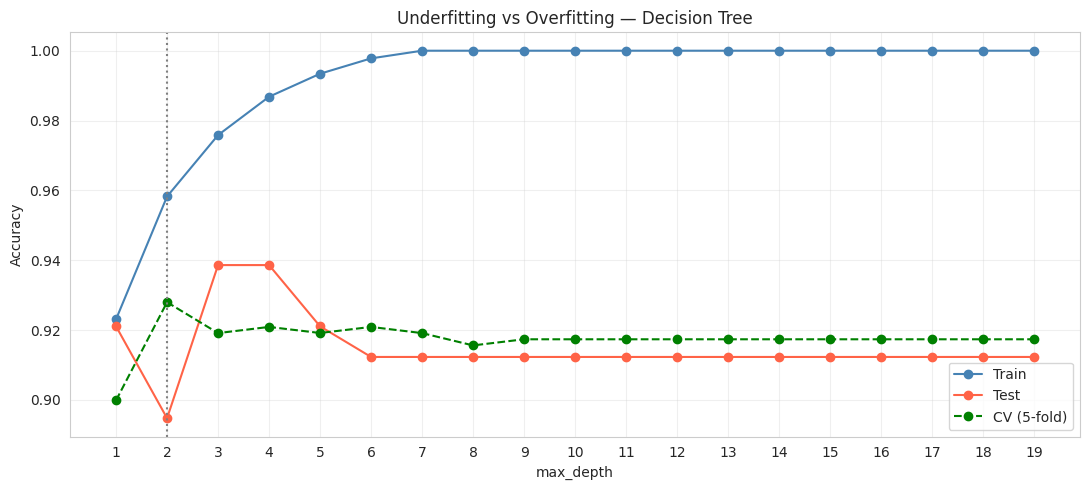

Best depth by CV: 2


In [85]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

depths = range(1, 20)
train_acc, test_acc, cv_acc = [], [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, dt.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, dt.predict(X_te)))
    cv_acc.append(cross_val_score(dt, X_cancer, y_cancer, cv=5).mean())

best_d = list(depths)[np.argmax(cv_acc)]

plt.figure(figsize=(11, 5))
plt.plot(depths, train_acc, marker='o', label='Train', color='steelblue')
plt.plot(depths, test_acc,  marker='o', label='Test',  color='tomato')
plt.plot(depths, cv_acc,    marker='o', label='CV (5-fold)', color='green', linestyle='--')
plt.axvline(best_d, color='gray', linestyle=':', linewidth=1.5)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Underfitting vs Overfitting — Decision Tree')
plt.legend()
plt.xticks(list(depths))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Best depth by CV: {best_d}')

## Q25: What is GridSearchCV and how does it work?

GridSearchCV exhaustively tries every combination of hyperparameters from a grid and evaluates each using cross-validation. It returns the combination with the best CV score.

**Naming inside a Pipeline:** use `stepname__param` — e.g. `'model__max_depth'`.

**Watch out:** with a large grid, the number of fits = `|combinations| × cv_folds`. 100 combinations × 5 folds = 500 model fits. Use `n_jobs=-1` to parallelise.

In [86]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scl',   StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid = {
    'model__n_neighbors': [3, 5, 7, 11, 15, 21],
    'model__weights':     ['uniform', 'distance']
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_cancer, y_cancer)

print('Best params: ', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))

Best params:  {'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best CV score: 0.9701


## Q26: What is RandomizedSearchCV and when should you use it instead of GridSearchCV?

GridSearchCV tries **every combination**. With large grids this is expensive. RandomizedSearchCV samples a **random subset** of parameter combinations — you control how many via `n_iter`.

**Rule of thumb:** use `GridSearchCV` for small grids (< ~100 combos); use `RandomizedSearchCV` for large grids or when parameters span wide continuous ranges.

In [87]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipe = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         [None, 3, 5, 7, 10],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10)
}

rand_search = RandomizedSearchCV(
    pipe, param_dist, n_iter=20, cv=5,
    scoring='accuracy', random_state=42, n_jobs=-1
)
rand_search.fit(X_cancer, y_cancer)

print('Best params: ', rand_search.best_params_)
print('Best CV score:', round(rand_search.best_score_, 4))

Best params:  {'model__max_depth': 7, 'model__min_samples_leaf': 2, 'model__min_samples_split': 7, 'model__n_estimators': 103}
Best CV score: 0.9596


---
# 8. Probability & Statistics

## Q27: What is a PMF, PDF, and CDF?

| | PMF | PDF | CDF |
|---|---|---|---|
| **Used for** | Discrete variables | Continuous variables | Both |
| **Gives** | P(X = x) | Density at x (not probability) | P(X ≤ x) |
| **Integrates to** | 1 (sum) | 1 (integral) | Reaches 1 at the right |

Example: rolling a die → PMF.  Height of a person → PDF.

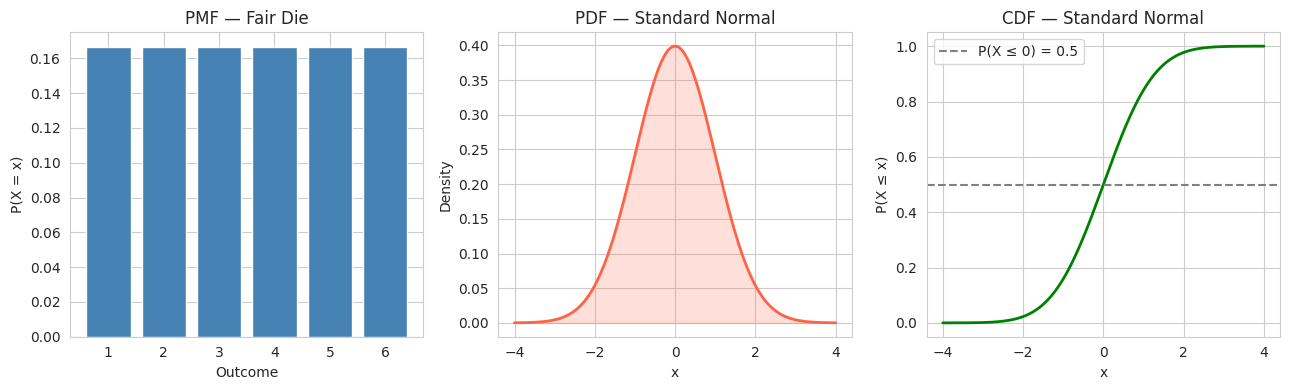

In [88]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# PMF — fair die
faces = np.arange(1, 7)
axes[0].bar(faces, [1/6]*6, color='steelblue', edgecolor='white')
axes[0].set_title('PMF — Fair Die')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('P(X = x)')

# PDF — standard normal
x = np.linspace(-4, 4, 300)
axes[1].plot(x, norm.pdf(x), color='tomato', linewidth=2)
axes[1].fill_between(x, norm.pdf(x), alpha=0.2, color='tomato')
axes[1].set_title('PDF — Standard Normal')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')

# CDF — standard normal
axes[2].plot(x, norm.cdf(x), color='green', linewidth=2)
axes[2].axhline(0.5, color='gray', linestyle='--', label='P(X ≤ 0) = 0.5')
axes[2].set_title('CDF — Standard Normal')
axes[2].set_xlabel('x')
axes[2].set_ylabel('P(X ≤ x)')
axes[2].legend()

plt.tight_layout()
plt.show()

## Q28: What is Bayes' Theorem?

Bayes' theorem updates the probability of a hypothesis given new evidence:

```
P(H | E) = P(E | H) × P(H) / P(E)
```

- **P(H)** — prior: what you believed before seeing evidence
- **P(E|H)** — likelihood: probability of evidence if hypothesis is true
- **P(H|E)** — posterior: updated belief after seeing evidence

This is the foundation of Naive Bayes classifiers and probabilistic ML.

In [89]:
# Medical test example
scenarios = [
    ('Rare disease (1%)',    0.01),
    ('Common disease (10%)', 0.10),
    ('Very common (40%)',    0.40),
]

sensitivity = 0.99   # P(test+ | disease)
fpr         = 0.05   # P(test+ | no disease)

print(f'Test sensitivity: {sensitivity*100:.0f}%  False positive rate: {fpr*100:.0f}%')
print('-' * 55)

for label, prevalence in scenarios:
    p_positive = sensitivity * prevalence + fpr * (1 - prevalence)
    posterior  = (sensitivity * prevalence) / p_positive
    print(f'{label:25s} → P(disease | positive) = {posterior:.2%}')

Test sensitivity: 99%  False positive rate: 5%
-------------------------------------------------------
Rare disease (1%)         → P(disease | positive) = 16.67%
Common disease (10%)      → P(disease | positive) = 68.75%
Very common (40%)         → P(disease | positive) = 92.96%


## Q29: What is Maximum Likelihood Estimation (MLE)?

MLE finds the parameter values that make the observed data most probable:

```
θ_MLE = argmax_θ  P(data | θ)
```

In practice we maximise the **log-likelihood** (easier to compute, same answer).

Example: estimating the mean and std of a Gaussian from data. MLE gives `μ = sample_mean`, `σ = sample_std`.

In [90]:
from scipy.stats import norm
from scipy.optimize import minimize

# Generate data from N(5, 2)
np.random.seed(42)
data = np.random.normal(loc=5, scale=2, size=200)

def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

result = minimize(neg_log_likelihood, x0=[0, 1], args=(data,),
                  bounds=[(None, None), (1e-6, None)])  # sigma must be > 0
mu_mle, sigma_mle = result.x

print(f'True    μ=5, σ=2')
print(f'MLE     μ={mu_mle:.3f}, σ={sigma_mle:.3f}')
print(f'Sample  μ={data.mean():.3f}, σ={data.std():.3f}')
# MLE = sample mean / sample std for Gaussian

True    μ=5, σ=2
MLE     μ=4.918, σ=1.857
Sample  μ=4.918, σ=1.857


/home/r00t/.cache/pypoetry/virtualenvs/backend--fSg5vju-py3.12/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


## Q29b: What is Variance (Dispersion) and Standard Deviation?

**Variance** measures how spread out values are around the mean:

```
Var(X) = E[(X − μ)²] = (1/n) Σ (xᵢ − μ)²   ← population
                       (1/(n-1)) Σ (xᵢ − μ)²  ← sample (Bessel's correction)
```

**Standard deviation** = √Var(X) — same units as the original variable.

| Concept | Formula | Meaning |
|---|---|---|
| Variance σ² | E[(X−μ)²] | Average squared deviation from mean |
| Std dev σ | √σ² | Typical distance from the mean |
| CV | σ/μ | Relative spread (unit-free) |

**In ML:** high-variance features carry more information but may need scaling. PCA finds directions of maximum variance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Three distributions with same mean, different variance
low_var  = rng.normal(0, 0.5, 1000)
mid_var  = rng.normal(0, 1.5, 1000)
high_var = rng.normal(0, 4.0, 1000)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, data, color, label in zip(
        axes,
        [low_var, mid_var, high_var],
        ['steelblue', 'tomato', 'green'],
        ['Low variance (σ=0.5)', 'Mid variance (σ=1.5)', 'High variance (σ=4.0)']):
    ax.hist(data, bins=50, color=color, alpha=0.7, density=True)
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.axvline(data.mean() + data.std(), color='orange', linestyle=':', label=f'±σ={data.std():.2f}')
    ax.axvline(data.mean() - data.std(), color='orange', linestyle=':')
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.suptitle('Same mean (0), different variance')
plt.tight_layout()
plt.show()

# Population vs sample variance
x = np.array([2., 4., 4., 4., 5., 5., 7., 9.])
print(f'Data: {x}')
print(f'Mean:              {x.mean():.4f}')
print(f'Population var:    {x.var():.4f}    (divides by n={len(x)})')
print(f'Sample var:        {x.var(ddof=1):.4f}  (divides by n-1={len(x)-1}, Bessel correction)')
print(f'Population std:    {x.std():.4f}')
print(f'Sample std:        {x.std(ddof=1):.4f}')
print(f'Coeff of variation:{x.std()/x.mean():.4f}  (relative spread)')


## Q29c: What is the Central Limit Theorem (CLT)?

**Statement:** If you draw n independent samples from *any* distribution with finite mean μ and variance σ², 
the distribution of the **sample mean** approaches a Normal distribution as n → ∞:

```
x̄ ~ N(μ,  σ²/n)
```

**What it means in practice:**
- No matter how weird your data distribution looks, averages of large samples are approximately normal.
- This is why we can use t-tests, confidence intervals, and p-values without assuming normality of raw data.
- Cross-validation scores are approximately normal — justifies reporting mean ± std.
- Standard error of the mean (SEM) = σ / √n — larger samples → tighter estimates.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(42)
n_experiments = 5000

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

distributions = [
    ('Uniform(0,1)',   lambda n: rng.uniform(0, 1, n),        0.5,    1/12),
    ('Exponential(1)', lambda n: rng.exponential(1, n),        1.0,    1.0 ),
    ('Bernoulli(0.3)', lambda n: rng.binomial(1, 0.3, n),      0.3,    0.21),
]

for col, (name, sampler, mu, var) in enumerate(distributions):
    # Raw distribution (n=1)
    raw = sampler(n_experiments)
    axes[col].hist(raw, bins=50, density=True, color='steelblue', alpha=0.7)
    axes[col].set_title(f'Raw: {name}')
    axes[col].set_ylabel('Density')

    # Distribution of sample means (n=30)
    n = 30
    means = np.array([sampler(n).mean() for _ in range(n_experiments)])
    sem = np.sqrt(var / n)
    x_range = np.linspace(means.min(), means.max(), 300)

    axes[col + 3].hist(means, bins=50, density=True, color='tomato', alpha=0.7, label=f'Sample means (n={n})')
    axes[col + 3].plot(x_range, norm.pdf(x_range, mu, sem), 'k-', linewidth=2, label='N(μ, σ²/n)')
    axes[col + 3].set_title(f'CLT: means of {name}')
    axes[col + 3].legend(fontsize=8)

plt.suptitle('Central Limit Theorem: sample means always approach Normal', fontsize=12)
plt.tight_layout()
plt.show()

# SEM shrinks with sample size
print('Standard Error of Mean (SEM = σ/√n) for N(0,1):')
for n in [5, 10, 30, 100, 1000]:
    print(f'  n={n:5d}: SEM = {1/np.sqrt(n):.4f}')


## Q29d: How do you visualize a distribution? (Complete toolkit)

| Plot | Best for | Watch out for |
|---|---|---|
| **Histogram** | Raw counts / density | Bin width changes the story |
| **KDE** (kernel density) | Smooth continuous shape | Over-smooths with small data |
| **Box plot** | Median, IQR, outliers | Hides shape (bimodal looks unimodal) |
| **Violin plot** | Shape + summary stats | Harder to read than box for non-experts |
| **ECDF** | Exact quantile reading | Less intuitive visually |
| **Q-Q plot** | Testing normality | Requires knowing expected distribution |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot, norm
import seaborn as sns

rng = np.random.default_rng(42)
data_normal  = rng.normal(0, 1, 500)
data_skewed  = rng.exponential(1, 500)
data_bimodal = np.concatenate([rng.normal(-2, 0.5, 250), rng.normal(2, 0.5, 250)])

datasets = [('Normal',  data_normal, 'steelblue'),
            ('Skewed',  data_skewed, 'tomato'),
            ('Bimodal', data_bimodal, 'green')]

fig, axes = plt.subplots(5, 3, figsize=(14, 18))

for col, (name, data, color) in enumerate(datasets):
    # Histogram + KDE
    axes[0, col].hist(data, bins=40, density=True, alpha=0.5, color=color)
    x = np.linspace(data.min(), data.max(), 300)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    axes[0, col].plot(x, kde(x), color=color, linewidth=2)
    axes[0, col].set_title(f'{name} — Histogram + KDE')

    # Box plot
    axes[1, col].boxplot(data, vert=False, patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.5))
    axes[1, col].set_title('Box plot')
    axes[1, col].set_xlabel('Value')

    # Violin plot
    axes[2, col].violinplot(data, vert=False)
    axes[2, col].set_title('Violin plot')

    # ECDF
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(data)+1) / len(data)
    axes[3, col].plot(sorted_data, ecdf, color=color, linewidth=1.5)
    axes[3, col].set_title('ECDF')
    axes[3, col].set_ylabel('P(X <= x)')
    axes[3, col].grid(True, alpha=0.3)

    # Q-Q plot (vs normal)
    probplot(data, dist='norm', plot=axes[4, col])
    axes[4, col].set_title(f'Q-Q plot vs Normal\n(straight line = normal)')

plt.suptitle('Distribution visualisation toolkit', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Q29e: What is the Kolmogorov-Smirnov (KS) Test?

The KS test answers: **are two distributions the same?**

It computes the **D-statistic** = maximum absolute difference between the two empirical CDFs:

```
D = max |F₁(x) − F₂(x)|
```

- Small D → distributions are similar
- p-value < 0.05 → distributions are **significantly different**

**ML use cases:**
- **Data drift detection:** is the production distribution different from training?
- **Train/test mismatch:** did stratification work?
- **Feature distribution check:** is the new batch from the same population?

Two variants:
- **One-sample:** compare data to a theoretical distribution (e.g. is this Normal?)
- **Two-sample:** compare two datasets

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, kstest, norm

rng = np.random.default_rng(42)

# ── One-sample KS: is data normally distributed? ──────────────────────────────
normal_data = rng.normal(0, 1, 300)
skewed_data = rng.exponential(1, 300)

stat_n, p_n = kstest(normal_data, 'norm', args=(0, 1))
stat_s, p_s = kstest(skewed_data, 'norm', args=(1, 1))
print('One-sample KS (vs Normal):')
print(f'  Normal data:  D={stat_n:.4f}, p={p_n:.4f}  -> {"SAME dist" if p_n > 0.05 else "DIFFERENT"}')
print(f'  Skewed data:  D={stat_s:.4f}, p={p_s:.4f}  -> {"SAME dist" if p_s > 0.05 else "DIFFERENT"}')

# ── Two-sample KS: train vs test distribution (drift example) ────────────────
train = rng.normal(0, 1, 500)
test_ok   = rng.normal(0, 1, 200)        # same distribution
test_drift = rng.normal(0.5, 1.5, 200)  # shifted + wider (drift!)

stat_ok,    p_ok    = ks_2samp(train, test_ok)
stat_drift, p_drift = ks_2samp(train, test_drift)
print('\nTwo-sample KS (train vs test):')
print(f'  No drift:    D={stat_ok:.4f}, p={p_ok:.4f}  -> {"OK" if p_ok > 0.05 else "DRIFT DETECTED!"}')
print(f'  With drift:  D={stat_drift:.4f}, p={p_drift:.4f}  -> {"OK" if p_drift > 0.05 else "DRIFT DETECTED!"}')

# Visualise the D-statistic
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, test, stat, p, title in [
        (axes[0], test_ok,    stat_ok,    p_ok,    'No drift'),
        (axes[1], test_drift, stat_drift, p_drift, 'Distribution drift')]:
    for arr, label, color in [(train, 'Train', 'steelblue'), (test, 'Test', 'tomato')]:
        s = np.sort(arr)
        ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color, linewidth=1.5)
    ax.set_title(f'{title}\nKS D={stat:.3f}, p={p:.4f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('CDF')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Q29f: What is KL Divergence (Kullback-Leibler)?

KL divergence measures **how different distribution Q is from reference distribution P**:

```
KL(P || Q) = Σ P(x) · log( P(x) / Q(x) )   ← discrete
           = ∫ p(x) · log( p(x) / q(x) ) dx  ← continuous
```

- KL = 0 → identical distributions
- KL > 0 → Q differs from P; larger = more different
- **Not symmetric:** KL(P‖Q) ≠ KL(Q‖P)

**vs KS test:**
| | KS test | KL divergence |
|---|---|---|
| Output | p-value (significance) | A number (magnitude) |
| Symmetric | Yes | No |
| Use | Hypothesis test | Distribution comparison / monitoring |

**ML use cases:** data drift monitoring, VAE loss (evidence lower bound), comparing predicted vs true distributions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy
from scipy.special import kl_div

# ── Discrete KL divergence ───────────────────────────────────────────────────
P = np.array([0.4, 0.3, 0.2, 0.1])  # reference (true distribution)
Q1 = np.array([0.4, 0.3, 0.2, 0.1])  # identical
Q2 = np.array([0.3, 0.3, 0.3, 0.1])  # slightly different
Q3 = np.array([0.1, 0.1, 0.1, 0.7])  # very different

print('Discrete KL divergence KL(P || Q):')
for label, Q in [('Q1 (identical)', Q1), ('Q2 (slight diff)', Q2), ('Q3 (very diff)', Q3)]:
    kl = scipy_entropy(P, Q)   # scipy entropy(P, Q) = KL(P||Q)
    kl_rev = scipy_entropy(Q, P)
    print(f'  {label:18s}: KL(P||Q)={kl:.4f}  KL(Q||P)={kl_rev:.4f}  <- asymmetry')

# ── Continuous KL divergence between Gaussians ───────────────────────────────
# KL(N(mu1,s1) || N(mu2,s2)) = log(s2/s1) + (s1² + (mu1-mu2)²)/(2*s2²) - 0.5
def kl_gaussians(mu1, s1, mu2, s2):
    return np.log(s2/s1) + (s1**2 + (mu1-mu2)**2) / (2*s2**2) - 0.5

print('\nContinuous KL between Gaussians:')
for mu2, s2, label in [(0, 1, 'Same N(0,1)'),
                        (1, 1, 'Shifted N(1,1)'),
                        (0, 2, 'Wider N(0,2)'),
                        (2, 3, 'Very different N(2,3)')]:
    kl = kl_gaussians(0, 1, mu2, s2)
    print(f'  KL(N(0,1) || N({mu2},{s2})): {kl:.4f}  — {label}')

# ── Visualise ─────────────────────────────────────────────────────────────────
x = np.linspace(-5, 8, 500)
from scipy.stats import norm
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ref = norm.pdf(x, 0, 1)
for ax, (mu, s, label) in zip(axes, [(0,1,'Same'), (1,1,'Shifted'), (2,2,'Different')]):
    q = norm.pdf(x, mu, s)
    ax.fill_between(x, ref, alpha=0.4, color='steelblue', label='P = N(0,1)')
    ax.fill_between(x, q,   alpha=0.4, color='tomato',    label=f'Q = N({mu},{s})')
    kl = kl_gaussians(0, 1, mu, s)
    ax.set_title(f'{label}\nKL(P||Q) = {kl:.3f}')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 0.5)
plt.suptitle('KL Divergence: how much Q differs from P')
plt.tight_layout()
plt.show()


---
# 9. Advanced Topics

## Q30: What is PCA (Principal Component Analysis)?

PCA finds the directions (principal components) of maximum variance in the data and projects data onto them. It:

1. **Reduces dimensionality** — keep top K components instead of all features
2. **Removes correlated features** — components are orthogonal by construction
3. **Helps visualisation** — project to 2D to see clusters

`explained_variance_ratio_` tells you how much variance each component captures.

Explained variance ratio: [0.443 0.19 ]
Together: 63.2% of variance


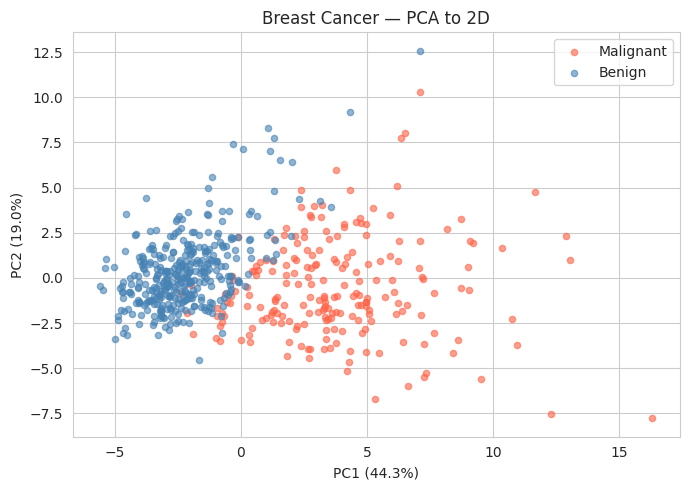

In [91]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cancer)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))
print(f'Together: {pca.explained_variance_ratio_.sum():.1%} of variance')

plt.figure(figsize=(7, 5))
for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
    mask = y_cancer == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.6, s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Breast Cancer — PCA to 2D')
plt.legend()
plt.tight_layout()
plt.show()

## Q30b: What is SVD (Singular Value Decomposition)?\n",
    "\n",
    "SVD decomposes any matrix **M** (m×n) into three matrices:\n",
    "\n",
    "```\n",
    "M = U · Σ · Vᵀ\n",
    "```\n",
    "\n",
    "| Matrix | Shape | Meaning |\n",
    "|---|---|---|\n",
    "| **U** | m×m | Left singular vectors — directions in row space |\n",
    "| **Σ** | m×n | Diagonal — singular values (importance of each direction) |\n",
    "| **Vᵀ** | n×n | Right singular vectors — directions in column space |\n",
    "\n",
    "**Truncated SVD:** keep only the top K singular values → best rank-K approximation of M (minimum Frobenius error).\n",
    "\n",
    "**Relation to PCA:** PCA is SVD applied to the mean-centred, scaled data matrix. The principal components are the columns of V."

M shape: (4, 3)
U: (4, 4)   Σ: (4, 3)   Vᵀ: (3, 3)
Singular values: [25.462  1.291  0.   ]
Reconstruction error: 0.0

Rank-K approximation error (Frobenius norm):
  K=1: 1.2907
  K=2: 0.0000
  K=3: 0.0000


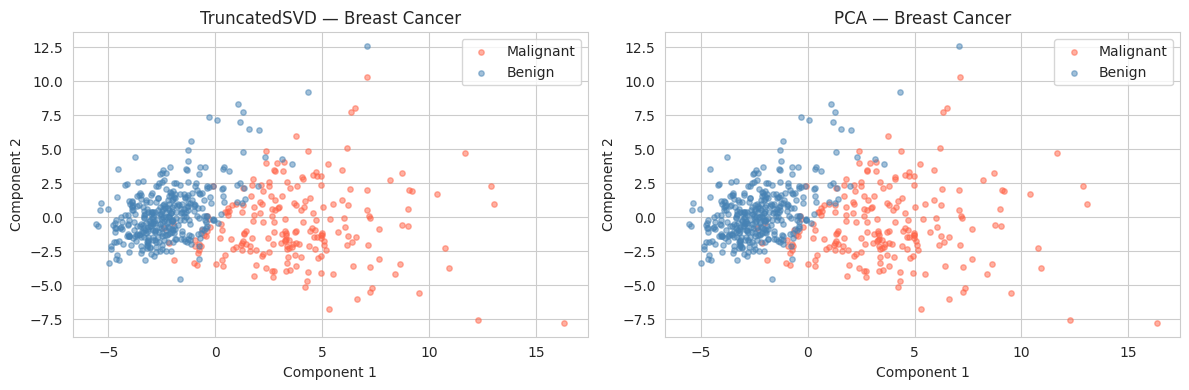

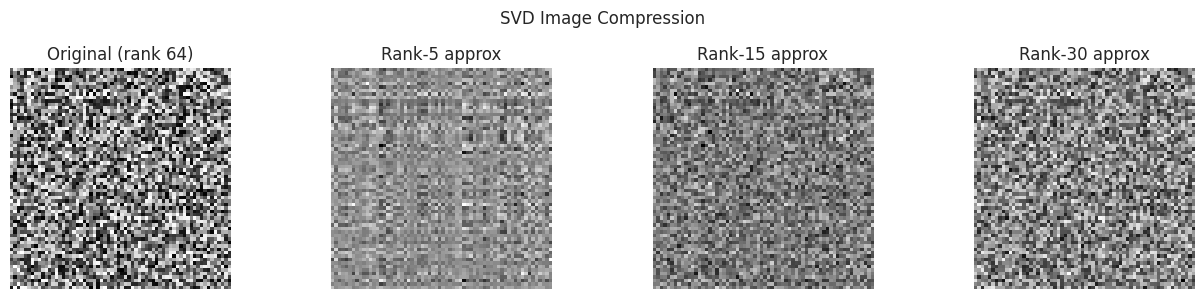

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ── 1. Full SVD ──────────────────────────────────────────────────────────────
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9],
              [10, 11, 12]], dtype=float)

U, s, Vt = np.linalg.svd(M, full_matrices=True)
Sigma = np.zeros(M.shape)
np.fill_diagonal(Sigma, s)

print('M shape:', M.shape)
print('U:', U.shape, '  Σ:', Sigma.shape, '  Vᵀ:', Vt.shape)
print('Singular values:', s.round(3))
print('Reconstruction error:', np.linalg.norm(M - U @ Sigma @ Vt).round(10))

# ── 2. Truncated SVD — rank-K approximation ───────────────────────────────────
print('\nRank-K approximation error (Frobenius norm):')
for k in [1, 2, 3]:
    M_approx = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(M - M_approx)
    print(f'  K={k}: {err:.4f}')

# ── 3. SVD for dimensionality reduction (vs PCA) ──────────────────────────────
from sklearn.decomposition import TruncatedSVD, PCA

X_scaled = StandardScaler().fit_transform(X_cancer)

# Both should give nearly identical 2-D projections
svd_proj = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_scaled)
pca_proj = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, proj, title in [(axes[0], svd_proj, 'TruncatedSVD'),
                         (axes[1], pca_proj, 'PCA')]:
    for cls, color, label in [(0, 'tomato', 'Malignant'), (1, 'steelblue', 'Benign')]:
        mask = y_cancer == cls
        ax.scatter(proj[mask, 0], proj[mask, 1], c=color, label=label, alpha=0.5, s=15)
    ax.set_title(f'{title} — Breast Cancer')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Image compression via SVD ─────────────────────────────────────────────
np.random.seed(42)
img = np.random.rand(64, 64)   # synthetic 64×64 "image"
U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (rank 64)')

for ax, k in zip(axes[1:], [5, 15, 30]):
    approx = U_img[:, :k] @ np.diag(s_img[:k]) @ Vt_img[:k, :]
    ax.imshow(approx, cmap='gray')
    ax.set_title(f'Rank-{k} approx')
for ax in axes:
    ax.axis('off')
plt.suptitle('SVD Image Compression')
plt.tight_layout()
plt.show()

## Q31: What is Feature Importance and how do you use it?

Tree-based models (Decision Tree, Random Forest) compute **feature importance** — how much each feature contributes to reducing impurity across all splits.

This answers: *which features actually matter?*

Uses:
- Remove unimportant features to simplify the model
- Understand what drives predictions
- Detect data leakage (suspiciously high importance)

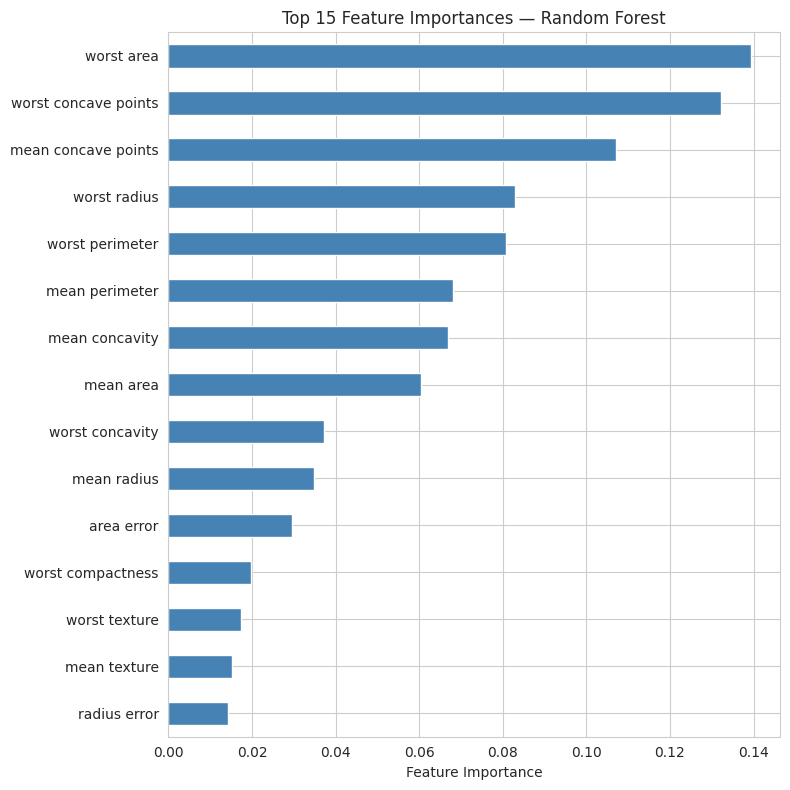

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_cancer, y_cancer)

importances = pd.Series(rf.feature_importances_, index=X_cancer.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importances.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## Q32: What is K-Means clustering?

K-Means partitions data into K clusters by iterating:
1. Assign each point to the nearest centroid
2. Recompute centroids as the mean of assigned points
3. Repeat until centroids stop moving

**Choosing K:** use the **elbow method** — plot inertia (sum of squared distances to nearest centroid) vs K and look for where the decrease flattens.

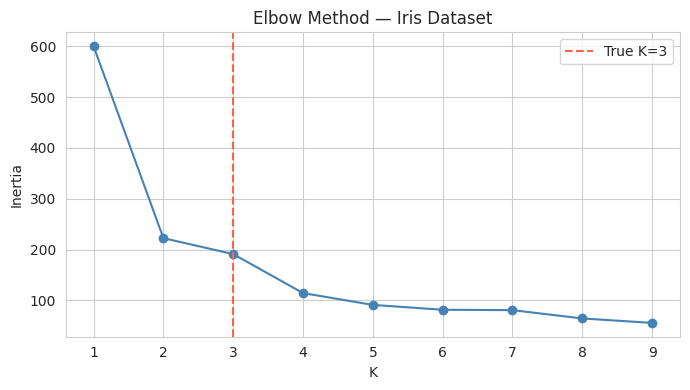

In [94]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_iris)

inertias = []
ks = range(1, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o', color='steelblue')
plt.axvline(3, color='tomato', linestyle='--', label='True K=3')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method — Iris Dataset')
plt.legend()
plt.tight_layout()
plt.show()

## Q33: How do you compare multiple models systematically?

Run the same cross-validation setup on all models and compare mean ± std. Use a held-out test set only once at the very end on the winner.

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'KNN (k=7)':          Pipeline([('scl', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=7))]),
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression':Pipeline([('scl', StandardScaler()), ('m', LogisticRegression(max_iter=1000))]),
    'Naive Bayes':        GaussianNB(),
    'SVM (rbf)':          Pipeline([('scl', StandardScaler()), ('m', SVC(kernel='rbf', random_state=42))]),
}

print(f'{"Model":25s}  {"CV Mean":>8}  {"CV Std":>7}')
print('-' * 45)
for name, model in models.items():
    s = cross_val_score(model, X_cancer, y_cancer, cv=5, scoring='accuracy')
    print(f'{name:25s}  {s.mean():.4f}    ±{s.std():.4f}')

Model                       CV Mean   CV Std
---------------------------------------------
KNN (k=7)                  0.9701    ±0.0089
Decision Tree              0.9191    ±0.0180
Random Forest              0.9561    ±0.0228
Logistic Regression        0.9807    ±0.0065
Naive Bayes                0.9385    ±0.0146
SVM (rbf)                  0.9736    ±0.0147


## Q34: What is data leakage and how do you prevent it?

Data leakage happens when information from the test set (or future data) influences training — making model performance look better than it actually is.

**Common sources:**
1. Fitting a scaler on all data before splitting
2. Imputing missing values with statistics from the full dataset
3. Feature engineering using target values
4. Time series: using future data to predict the past

**Prevention: always use a Pipeline.** `cross_val_score(pipeline, ...)` fits preprocessing fresh on each fold's training data.

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# WRONG: scale before CV — test fold statistics leak into training
X_leaked = StandardScaler().fit_transform(X_cancer)   # fit on ALL data first
score_leaked = cross_val_score(KNeighborsClassifier(n_neighbors=7),
                               X_leaked, y_cancer, cv=5).mean()

# CORRECT: scaler inside pipeline — fitted only on each fold's train split
pipe = Pipeline([('scl', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7))])
score_correct = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()

print(f'Leaked   CV accuracy: {score_leaked:.4f}')
print(f'Correct  CV accuracy: {score_correct:.4f}')
print('(On large, clean datasets the difference is small but the principle is critical)')

Leaked   CV accuracy: 0.9684
Correct  CV accuracy: 0.9701
(On large, clean datasets the difference is small but the principle is critical)


---
# 10. Feature Engineering

## FE1: What is feature engineering and why does it matter?

Feature engineering = creating or transforming input features to make patterns easier for the model to learn.

**Types of transformations:**
| Technique | When to use | Example |
|---|---|---|
| **Log transform** | Right-skewed distributions | Price, income, population |
| **Polynomial features** | Nonlinear relationships | x² or x₁·x₂ interaction |
| **Binning** | Continuous → categorical | Age groups: 0-18, 18-35, ... |
| **Ratio features** | Domain-derived ratios | income/expense, area/rooms |
| **Date/time extraction** | Timestamp features | hour_of_day, day_of_week |
| **Interaction terms** | Combined effect of two features | bmi × age |

**Rule:** a well-engineered feature often beats a more complex model on raw features.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

rng = np.random.default_rng(42)

# ── 1. Log transform for skewed data ────────────────────────────────────────
income = rng.exponential(scale=50000, size=1000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(income, bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Raw income (right-skewed)')
axes[1].hist(np.log1p(income), bins=50, color='tomato', alpha=0.7)
axes[1].set_title('log(income+1) — more symmetric')
plt.tight_layout()
plt.show()

# ── 2. Polynomial features capture nonlinear patterns ────────────────────────
x_raw = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = x_raw.ravel()**2 + rng.normal(0, 0.5, 100)

results = {}
for degree in [1, 2, 5]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)),
                     ('lr',   LinearRegression())])
    score = cross_val_score(pipe, x_raw, y_true, cv=5, scoring='r2').mean()
    results[degree] = score

plt.figure(figsize=(7, 4))
for degree, color in [(1,'tomato'),(2,'steelblue'),(5,'green')]:
    pipe = Pipeline([('poly', PolynomialFeatures(degree=degree)), ('lr', LinearRegression())])
    pipe.fit(x_raw, y_true)
    plt.plot(x_raw, pipe.predict(x_raw), color=color, linewidth=2,
             label=f'degree={degree}, CV R²={results[degree]:.3f}')
plt.scatter(x_raw, y_true, alpha=0.3, s=10, color='gray')
plt.title('Polynomial Features: capturing nonlinear relationships')
plt.legend()
plt.tight_layout()
plt.show()

# ── 3. Interaction term example ───────────────────────────────────────────────
df = pd.DataFrame({
    'age':    rng.integers(20, 70, 200).astype(float),
    'bmi':    rng.normal(25, 5, 200),
})
df['age_x_bmi'] = df['age'] * df['bmi']          # interaction feature
df['bmi_sq']    = df['bmi'] ** 2                  # polynomial feature
df['log_bmi']   = np.log(df['bmi'].clip(lower=1)) # log transform

print('Original features:', list(df.columns[:2]))
print('Engineered features:', list(df.columns[2:]))
print(df.head())


## FE2: How do you handle date/time features and cyclical encoding?

Raw timestamps must be decomposed into numeric features. Some features are **cyclical** — hour 23 and hour 0 are adjacent. 
Encoding them as integers (0–23) makes 0 and 23 seem far apart. 

**Solution:** encode cyclical features as (sin, cos) pairs:

```
hour_sin = sin(2π × hour / 24)
hour_cos = cos(2π × hour / 24)
```

This preserves the circular structure.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Date/time feature extraction
dates = pd.date_range('2024-01-01', periods=365, freq='D')
df = pd.DataFrame({'date': dates, 'sales': np.sin(np.arange(365)*2*np.pi/365)*100 + 200})

df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['day_of_week']= df['date'].dt.dayofweek
df['day_of_year']= df['date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Cyclical encoding for month (1-12) and day of week (0-6)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Features after date decomposition:')
print(df[['date','month','month_sin','month_cos','is_weekend']].head(7))

# Visualise cyclical encoding — months form a circle
plt.figure(figsize=(5, 5))
sc = plt.scatter(df['month_sin'], df['month_cos'],
                  c=df['month'], cmap='hsv', s=30, alpha=0.7)
plt.colorbar(sc, label='Month')
plt.xlabel('month_sin')
plt.ylabel('month_cos')
plt.title('Cyclical month encoding — forms a circle\nJan and Dec are adjacent (correct!)')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# 10. Linear Algebra for ML

## LA1: How is data represented as a matrix and what is a vector?

A **dataset** is a matrix **X** of shape (n_samples x n_features):
- Each **row** = one sample (observation)
- Each **column** = one feature

A **vector** is a 1-D array. Every ML prediction is a matrix operation:

    y_hat = X @ w + b

All preprocessing (scaling, PCA, encoding) is a matrix transformation under the hood.

In [ ]:
import numpy as np

X = np.array([[1.2, 0.5, 3.1],
              [2.4, 1.1, 0.8],
              [0.3, 2.2, 1.5],
              [1.8, 0.9, 2.7]])
print('Data matrix X (4 samples x 3 features):')
print(X)
print(f'Shape: {X.shape}')

print(f'\nSample 0 (row vector): {X[0]}')
print(f'Feature 1 (column vector): {X[:, 1]}')

w = np.array([0.5, -0.3, 1.0])  # learned weights
b = 0.1
y_hat = X @ w + b
print(f'\nPredictions y = Xw + b: {y_hat.round(3)}')

## LA2: What is Euclidean space and distance?

**Euclidean space R^n** is the n-dimensional real-number space where each point is a vector of n coordinates. Distance between two points is the L2 norm of their difference:

    d(a, b) = ||a - b||_2 = sqrt(sum (a_i - b_i)^2)

This is the distance KNN uses. Scaling features to the same range is critical — otherwise features with larger absolute values dominate the distance calculation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])

d_euclidean = np.linalg.norm(a - b)
d_manhattan = np.linalg.norm(a - b, 1)
print(f'a = {a},  b = {b}')
print(f'Euclidean distance: {d_euclidean:.4f}  (sqrt((4-1)^2 + (6-2)^2))')
print(f'Manhattan distance: {d_manhattan:.4f}  (|4-1| + |6-2|)')

# Why scaling matters for KNN
p1 = np.array([1.0,    1000.0])  # age=1, income=1000
p2 = np.array([1.0,    2000.0])  # age=1, income=2000
p3 = np.array([50.0,   1001.0])  # age=50, income=1001
print('\nWithout scaling:')
print(f'  d(p1, p2) = {np.linalg.norm(p1-p2):.1f}  (differ only in income)')
print(f'  d(p1, p3) = {np.linalg.norm(p1-p3):.1f}  (differ heavily in age)')
print('  KNN would say p1 and p3 are farther apart even though income difference is tiny')

from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform([p1, p2, p3])
print('\nAfter StandardScaler:')
print(f'  d(p1, p2) = {np.linalg.norm(scaled[0]-scaled[1]):.3f}')
print(f'  d(p1, p3) = {np.linalg.norm(scaled[0]-scaled[2]):.3f}')

## LA3: What is an orthonormal basis?

A set of vectors forms an **orthonormal basis** when:
1. **Orthogonal:** every pair of vectors is perpendicular (dot product = 0)
2. **Normal (unit length):** every vector has L2 norm = 1

Why it matters in ML:
- PCA principal components are an orthonormal basis of the feature space
- The U and V matrices in SVD are orthonormal
- Projecting onto an orthonormal basis is computationally cheap: just a dot product
- Projections are non-overlapping — each component captures unique variance

In [ ]:
import numpy as np

# Standard basis of R^3 (canonical example)
e1 = np.array([1., 0., 0.])
e2 = np.array([0., 1., 0.])
e3 = np.array([0., 0., 1.])

print('Standard basis of R^3:')
for i, (u, v) in enumerate([(e1,e2),(e1,e3),(e2,e3)]):
    print(f'  e{i+1} dot e{i+2}: {np.dot(u,v):.1f}  (should be 0 = orthogonal)')
for i, e in enumerate([e1, e2, e3]):
    print(f'  ||e{i+1}|| = {np.linalg.norm(e):.1f}  (should be 1 = unit length)')

# PCA components are orthonormal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

X_iris, _ = load_iris(return_X_y=True)
X_sc = StandardScaler().fit_transform(X_iris)
pca = PCA(n_components=4).fit(X_sc)
V = pca.components_  # shape (4, 4) — each row is a principal component

print('\nPCA components are orthonormal:')
print('  V @ V.T (should be identity):')
print((V @ V.T).round(10))

# Projection: coordinates of data in PC space = just a matrix multiply
X_proj = X_sc @ V.T  # same as pca.transform(X_sc)
print(f'\nProjected data shape: {X_proj.shape}  (150 samples x 4 components)')
print(f'Variance per component: {pca.explained_variance_ratio_.round(3)}')

## LA4: What is matrix rank — and what does rank-K mean in SVD/PCA?

The **rank** of a matrix = number of linearly independent rows (or columns) = the true number of dimensions the data spans.

In SVD: `M = U S V^T` where S is diagonal with singular values s_1 >= s_2 >= ... >= s_r > 0.
The rank equals the number of **non-zero singular values**.

**Rank-K approximation** keeps only the K largest singular values:

    M_K = U[:, :K] @ diag(s[:K]) @ V^T[:K, :]

This is the *closest* rank-K matrix to M (Eckart-Young theorem). Each kept component captures the next most important direction of variation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix rank
A_full = np.array([[1.,0.,0.],[0.,2.,0.],[0.,0.,3.]])
A_rank2 = np.array([[1.,2.,3.],[4.,5.,6.],[5.,7.,9.]])  # row3=row1+row2
print(f'Full-rank matrix rank: {np.linalg.matrix_rank(A_full)}')
print(f'Rank-deficient matrix rank: {np.linalg.matrix_rank(A_rank2)} (3x3 but rank=2)')

U, s, Vt = np.linalg.svd(A_rank2)
print(f'Singular values: {s.round(6)}  <- last one ~0 confirms rank=2')

# Rank-K approximation quality
rng = np.random.default_rng(0)
M = rng.normal(size=(30, 15))
U, s, Vt = np.linalg.svd(M, full_matrices=False)
total_var = (s**2).sum()

print(f'\nRank-K approximation of a 30x15 matrix:')
print(f'  {"K":>3}  {"Var explained":>14}  {"Frobenius error":>16}')
for k in [1, 3, 5, 10, 15]:
    M_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    var = (s[:k]**2).sum() / total_var
    err = np.linalg.norm(M - M_k, 'fro')
    print(f'  {k:>3}  {var:>13.1%}  {err:>16.4f}')

# Scree plot: variance explained by each singular value
var_explained = (s**2) / total_var
plt.figure(figsize=(7, 3))
plt.bar(range(1, len(s)+1), var_explained, color='steelblue')
plt.plot(range(1, len(s)+1), np.cumsum(var_explained), 'ro-', label='Cumulative')
plt.axhline(0.9, color='gray', linestyle='--', label='90% threshold')
plt.xlabel('Singular value index (component)')
plt.ylabel('Variance explained')
plt.title('Scree Plot — how much variance each component adds')
plt.legend()
plt.tight_layout()
plt.show()

## LA5: Key matrix operations — dot product, transpose, inverse, determinant

| Operation | Code | When used in ML |
|---|---|---|
| Dot product | `np.dot(a, b)` | Similarity; every linear model prediction |
| Matrix multiply | `A @ B` | Apply transformations; batch predictions |
| Transpose | `A.T` | OLS formula `(X^T X)^{-1} X^T y` |
| Inverse | `np.linalg.inv(A)` | OLS closed-form solution |
| Determinant | `np.linalg.det(A)` | Checks if matrix is invertible (det=0 -> singular) |

In [ ]:
import numpy as np

a = np.array([1., 2., 3.])
b = np.array([4., 5., 6.])

# Dot product
print(f'a . b = {np.dot(a, b)}  (= 1*4 + 2*5 + 3*6)')
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f'angle(a, b) = {np.degrees(np.arccos(cos_theta)):.2f} deg')

# Transpose
A = np.array([[1,2,3],[4,5,6]])
print(f'\nA shape {A.shape}  ->  A.T shape {A.T.shape}')

# Inverse
M = np.array([[2., 1.],[1., 3.]])
M_inv = np.linalg.inv(M)
print(f'\nM @ M_inv (identity check):')
print((M @ M_inv).round(10))

# Determinant
print(f'\ndet(M) = {np.linalg.det(M):.4f}  (non-zero -> invertible)')
singular = np.array([[1., 2.],[2., 4.]])  # linearly dependent rows
print(f'det(singular) = {np.linalg.det(singular):.4f}  -> not invertible')

# OLS closed form: w = (X^T X)^-1 X^T y
rng = np.random.default_rng(42)
X_d = rng.normal(size=(50, 2))
y_d = 3*X_d[:,0] - 2*X_d[:,1] + rng.normal(scale=0.1, size=50)
X_b = np.hstack([np.ones((50,1)), X_d])
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_d
print(f'\nOLS w = (X^T X)^-1 X^T y:')
print(f'  intercept={w_ols[0]:.3f}, w1={w_ols[1]:.3f}, w2={w_ols[2]:.3f}')
print(f'  True: intercept=0, w1=3, w2=-2')

## LA6: What are eigenvalues and eigenvectors — the foundation of PCA?

For a square matrix **A**, an **eigenvector** v is a special direction that A only *stretches*, never *rotates*:

    A v = lambda v

- **v** = eigenvector (direction preserved by the transformation)
- **lambda** = eigenvalue (stretch factor)

**PCA:** computes the covariance matrix of the (centred, scaled) data, then finds its eigenvectors. These are the principal components — directions of maximum variance. Larger eigenvalue = more important direction.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3., 1.],[1., 3.]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print('A:', A)
print(f'Eigenvalues:  {eigenvalues}')
print(f'Eigenvectors (columns):\n{eigenvectors}')

for i in range(2):
    v = eigenvectors[:, i]
    lv = eigenvalues[i]
    print(f'\nA @ v{i} = {(A @ v).round(6)}')
    print(f'lv{i} * v{i} = {(lv * v).round(6)}  <- same')

# PCA via covariance matrix eigenvectors
rng = np.random.default_rng(42)
x1 = rng.normal(0, 2, 300)
x2 = 0.8*x1 + rng.normal(0, 0.6, 300)
X2d = np.column_stack([x1, x2])
cov = np.cov(X2d.T)
evals, evecs = np.linalg.eig(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
print(f'\nCovariance eigenvalues: {evals.round(3)}')
print(f'Variance explained: {(evals/evals.sum()).round(3)}')

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], alpha=0.3, s=10)
origin = X2d.mean(axis=0)
for i in range(2):
    vec = evecs[:, i]
    scale = np.sqrt(evals[i])
    plt.annotate('', xy=origin + scale*vec, xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=['tomato','steelblue'][i], lw=2.5))
    plt.text(*(origin + scale*vec*1.1), f'PC{i+1} (lv={evals[i]:.2f})', fontsize=10,
             color=['tomato','steelblue'][i])
plt.axis('equal')
plt.title('Eigenvectors of Covariance Matrix = Principal Components')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA7: What are vector/matrix norms?

A **norm** measures the size of a vector or matrix.

| Norm | Formula | Name | Used for |
|---|---|---|---|
| L1 | sum |x_i| | Manhattan | Lasso penalty; sparse signals |
| L2 | sqrt(sum x_i^2) | Euclidean | KNN distance; Ridge penalty |
| L-inf | max |x_i| | Chebyshev | Worst-case error |
| Frobenius | sqrt(sum A_ij^2) | Matrix L2 | SVD approximation error |

L1 norms encourage **sparsity** (corners of the constraint ball lie on axes). L2 norms encourage **small but non-zero** weights.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([3., -4., 0., 1.])
print(f'v = {v}')
print(f'L1 norm: {np.linalg.norm(v, 1):.4f}  = |3|+|-4|+|0|+|1|')
print(f'L2 norm: {np.linalg.norm(v, 2):.4f}  = sqrt(9+16+0+1)')
print(f'Linf norm: {np.linalg.norm(v, np.inf):.4f}  = max(3,4,0,1)')

A = np.array([[1.,2.],[3.,4.]])
print(f'Frobenius norm: {np.linalg.norm(A, "fro"):.4f}  = sqrt(1+4+9+16)')

# L1 vs L2 unit balls in 2D
theta = np.linspace(0, 2*np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, p, title, color in [
        (axes[0], 1, 'L1 ball (diamond) -> sparse', 'tomato'),
        (axes[1], 2, 'L2 ball (circle) -> dense',   'steelblue')]:
    pts = np.column_stack([np.cos(theta), np.sin(theta)])
    r = 1.0 / (np.sum(np.abs(pts)**p, axis=1)**(1/p) + 1e-12)
    pts_s = pts * r[:, None]
    ax.plot(pts_s[:, 0], pts_s[:, 1], color=color, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA8: What is Least Squares and how is it derived?

**Goal:** find weights **w** that minimise the sum of squared errors between predictions and targets:

    Loss(w) = ||Xw - y||_2^2 = (Xw - y)^T (Xw - y)

**Derivation:** take the gradient, set to zero:

    dLoss/dw = 2 X^T (Xw - y) = 0
    X^T X w = X^T y
    w = (X^T X)^{-1} X^T y     <- Normal equations

This is the **OLS (Ordinary Least Squares)** solution — the unique global minimum when X has full column rank.

When X is nearly singular (collinear features), `(X^T X)^{-1}` becomes numerically unstable. Ridge regression adds `alpha * I` to fix this: `w = (X^T X + alpha I)^{-1} X^T y`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
rng = np.random.default_rng(42)
x = np.linspace(0, 5, 50)
y = 2.0 * x + 1.0 + rng.normal(scale=0.8, size=50)

# OLS via normal equations
X_b = np.column_stack([np.ones_like(x), x])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f'OLS via normal equations:')
print(f'  intercept = {w_ols[0]:.4f}  (true: 1.0)')
print(f'  slope     = {w_ols[1]:.4f}  (true: 2.0)')

# Verify: same as sklearn
from sklearn.linear_model import LinearRegression, Ridge
lr_sk = LinearRegression().fit(x.reshape(-1,1), y)
print(f'\nsklearn LinearRegression: intercept={lr_sk.intercept_:.4f}, slope={lr_sk.coef_[0]:.4f}')

# Ridge = (X^T X + alpha I)^-1 X^T y
alpha = 1.0
n_feat = X_b.shape[1]
w_ridge = np.linalg.inv(X_b.T @ X_b + alpha * np.eye(n_feat)) @ X_b.T @ y
print(f'\nRidge (alpha=1) via closed form: intercept={w_ridge[0]:.4f}, slope={w_ridge[1]:.4f}')

# Plot fit
x_line = np.linspace(0, 5, 100)
plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_line, w_ols[0] + w_ols[1]*x_line, 'r-', linewidth=2, label='OLS fit')
plt.plot(x_line, w_ridge[0] + w_ridge[1]*x_line, 'g--', linewidth=2, label='Ridge fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()

## LA9: OLS vs Gradient Descent — when to use which?

Both solve the same linear regression problem, but differently:

| | OLS (Normal Equations) | Gradient Descent |
|---|---|---|
| **Method** | Exact closed-form solution | Iterative approximation |
| **Formula** | w = (XᵀX)⁻¹Xᵀy | w ← w − α∇Loss |
| **Speed (small data)** | Fast | Slower (many iterations) |
| **Speed (large data)** | Slow — O(p³) matrix inversion | Fast — O(n·p) per step |
| **Hyperparameters** | None | Learning rate α, n_iterations |
| **Numerical stability** | Fails if XᵀX is singular | Always applicable |
| **Generalises to** | Linear models only | Any differentiable loss (neural nets!) |

**Rule:** use OLS when n_features is small (< ~10k). Use gradient descent / SGD for large-scale problems.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

for n, p in [(500, 5), (10_000, 100)]:
    X = rng.normal(size=(n, p))
    w_true = rng.normal(size=p)
    y = X @ w_true + rng.normal(scale=0.5, size=n)

    # OLS
    t0 = time.perf_counter()
    X_b = np.hstack([np.ones((n,1)), X])
    w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    t_ols = time.perf_counter() - t0

    # SGD
    t0 = time.perf_counter()
    sgd = Pipeline([('scl', StandardScaler()),
                    ('sgd', SGDRegressor(max_iter=1000, random_state=42))])
    sgd.fit(X, y)
    t_sgd = time.perf_counter() - t0

    ols_err = np.mean((X @ w_ols[1:] + w_ols[0] - y)**2)
    sgd_err = np.mean((sgd.predict(X) - y)**2)

    print(f'n={n:6d}, p={p:3d}:  OLS {t_ols*1000:6.1f}ms MSE={ols_err:.4f} | '
          f'SGD {t_sgd*1000:6.1f}ms MSE={sgd_err:.4f}')

# ── Visualise gradient descent convergence ───────────────────────────────────
rng2 = np.random.default_rng(0)
x1d = rng2.uniform(0, 5, 80)
y1d = 2*x1d + 1 + rng2.normal(0, 0.8, 80)
X1d = np.column_stack([np.ones_like(x1d), x1d])

def gd_path(X, y, lr, n_iter=200):
    w = np.zeros(X.shape[1])
    losses, ws = [], []
    for _ in range(n_iter):
        grad = (2/len(y)) * X.T @ (X @ w - y)
        w = w - lr * grad
        losses.append(np.mean((X @ w - y)**2))
        ws.append(w.copy())
    return losses, ws

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
for lr, color in [(0.001,'tomato'),(0.01,'steelblue'),(0.05,'green')]:
    losses, _ = gd_path(X1d, y1d, lr)
    axes[0].plot(losses, color=color, label=f'lr={lr}')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (log scale)')
axes[0].set_title('GD convergence by learning rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weight trajectory (parameter space)
_, ws = gd_path(X1d, y1d, 0.01)
ws = np.array(ws)
axes[1].plot(ws[:, 0], ws[:, 1], 'o-', markersize=2, linewidth=1, color='steelblue')
axes[1].scatter([ws[-1,0]], [ws[-1,1]], color='red', s=80, zorder=5, label='Converged')
axes[1].scatter([ws[0,0]],  [ws[0,1]],  color='green', s=80, zorder=5, label='Start')
w_ols_1d = np.linalg.inv(X1d.T@X1d)@X1d.T@y1d
axes[1].scatter([w_ols_1d[0]], [w_ols_1d[1]], color='orange', s=120, zorder=5,
                marker='*', label=f'OLS exact')
axes[1].set_xlabel('w0 (intercept)')
axes[1].set_ylabel('w1 (slope)')
axes[1].set_title('Gradient descent path in parameter space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Summary Table

| Topic | Key concept | Covered in |
|---|---|---|
| Train-test split | Honest evaluation | Q2 |
| Cross-validation | Stable score estimate | Q3 |
| Missing values | SimpleImputer | Q4 |
| Scaling | StandardScaler / MinMaxScaler | Q5 |
| Encoding | OneHotEncoder | Q6 |
| Pipeline | Prevent leakage | Q7, Q34 |
| ColumnTransformer | Mixed data types | Q8 |
| KNN | Distance-based voting | Q9 |
| Decision Tree | Recursive splitting | Q10 |
| Random Forest | Ensemble / bagging | Q11 |
| Logistic Regression | Sigmoid / linear boundary | Q12 |
| Naive Bayes | Bayes + independence | Q13 |
| SVM | Max-margin hyperplane | Q14 |
| Linear Regression (OLS) | Closed-form least squares | Q15 |
| Gradient Descent | Iterative optimisation | Q16 |
| Regularisation (L1/L2) | Ridge, Lasso | Q17 |
| Confusion Matrix | TP/TN/FP/FN | Q18 |
| Accuracy/Precision/Recall/F1 | Classification metrics | Q19 |
| ROC-AUC | Threshold-free ranking | Q20 |
| MAE / MSE / RMSE | Regression error | Q21 |
| R² | Explained variance | Q22 |
| Parameters vs Hyperparameters | What the model learns vs what you set | Q23 |
| Overfitting / Underfitting | Bias-variance tradeoff | Q24 |
| GridSearchCV | Exhaustive tuning | Q25 |
| RandomizedSearchCV | Efficient large-grid tuning | Q26 |
| PMF / PDF / CDF | Probability distributions | Q27 |
| Bayes' Theorem | Prior → posterior | Q28 |
| MLE | Fit distributions to data | Q29 |
| PCA | Dimensionality reduction | Q30 |
| Feature Importance | Which features matter | Q31 |
| K-Means | Unsupervised clustering | Q32 |
| Model comparison | CV across all models | Q33 |
| Data leakage | Pipeline prevents it | Q34 |
| Ridge/Lasso geometry | Paths, sparsity, L1 vs L2 | Q17b |
| Classification metrics guide | When to use, interpretation | Q20b |
| Regression metrics guide | MAE vs RMSE gap, residuals | Q22b |
| Data as matrix | Rows=samples, cols=features | LA1 |
| Euclidean space & distance | L2 norm, why scaling matters | LA2 |
| Orthonormal basis | PCA components, projections | LA3 |
| Matrix rank & rank-K | SVD approximation | LA4 |
| Matrix operations | dot, @, transpose, inverse, det | LA5 |
| Eigenvalues/eigenvectors | PCA geometric foundation | LA6 |
| Norms (L1/L2/Frobenius) | Regularisation, distances | LA7 |
| Least Squares | Normal equations, Ridge extension | LA8 |
| Typical ML pipeline flow | EDA→FE→preprocess→tune→evaluate | Q3b |
| Normalization types | Min-Max vs Z-score vs L2 | Q5b |
| Pearson / Spearman correlation | Feature selection, target correlation | Q5c |
| Variance & dispersion | σ², std, CV, population vs sample | Q29b |
| Central Limit Theorem | Sample means → Normal | Q29c |
| Distribution visualisation | Histogram, KDE, box, violin, ECDF, Q-Q | Q29d |
| KS test | Distribution equality, drift detection | Q29e |
| KL divergence | Distribution distance, asymmetry | Q29f |
| Feature engineering | Log, poly, interactions, cyclical | FE1-FE2 |
| OLS vs Gradient Descent | Complexity, when to use | LA9 |